# MVP v2: Link Prediction for Drug-Disease Adverse Outcome Prediction

**Shift from hand-crafted feature engineering (MVP v1) to link prediction methodology.**

**Task:** Predict contraindication (1) vs indication (0) for (drug, disease) pairs.

**Three graph configurations:**
1. **Graph A** — PrimeKG without bio edges (bipartite: drugs ↔ diseases only)
2. **Graph B** — Full PrimeKG (all node/edge types)
3. **Graph C** — PrimeKG + DisGeNET disease-gene edges

**Three link prediction methods:**
1. Heuristic scores (CN, AA, JC, PA, RA) → RF
2. Node2Vec embeddings → RF
3. Combined (heuristics + embeddings) → RF

**Dataset:** 328 diseases, 1000 drugs, 14,824 samples from PrimeKG

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import random
from collections import defaultdict
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, auc
from sklearn.base import clone
from gensim.models import Word2Vec
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
pd.set_option('display.max_columns', None)
print("Dependencies loaded.")

Dependencies loaded.


## 2. Load PrimeKG Data & Select Diseases/Drugs

Reuse same selection logic as MVP v1: 328 diseases with good class balance, top 1000 drugs.

In [3]:
DATA_PATH = "data/kg.csv"
print("Loading PrimeKG...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {df.shape[0]:,} edges, {df.shape[1]} columns")

# Extract and normalize drug-disease edges (vectorized)
drug_disease_mask = (
    ((df['x_type'] == 'drug') & (df['y_type'] == 'disease')) |
    ((df['x_type'] == 'disease') & (df['y_type'] == 'drug'))
)
drug_disease_df = df[drug_disease_mask].copy()

# Vectorized normalization: put drug in x, disease in y
is_drug_x = drug_disease_df['x_type'] == 'drug'
drug_disease_normalized = pd.DataFrame({
    'drug_id': np.where(is_drug_x, drug_disease_df['x_id'].values, drug_disease_df['y_id'].values),
    'drug_name': np.where(is_drug_x, drug_disease_df['x_name'].values, drug_disease_df['y_name'].values),
    'disease_id': np.where(is_drug_x, drug_disease_df['y_id'].values, drug_disease_df['x_id'].values),
    'disease_name': np.where(is_drug_x, drug_disease_df['y_name'].values, drug_disease_df['x_name'].values),
    'relation': drug_disease_df['relation'].values
})

contraindications = drug_disease_normalized[drug_disease_normalized['relation'] == 'contraindication']
indications = drug_disease_normalized[drug_disease_normalized['relation'] == 'indication']
off_label = drug_disease_normalized[drug_disease_normalized['relation'] == 'off-label use']

print(f"Contraindications: {len(contraindications):,}")
print(f"Indications: {len(indications):,}")
print(f"Off-label: {len(off_label):,}")

Loading PrimeKG...
Loaded: 8,100,498 edges, 12 columns
Contraindications: 61,350
Indications: 18,776
Off-label: 5,136


In [4]:
# Select 328 diseases with both contraindications & indications (>=20% minority class)
diseases_with_both = set(contraindications['disease_id']) & set(indications['disease_id'])

disease_contra_counts = contraindications[contraindications['disease_id'].isin(diseases_with_both)].groupby(['disease_id', 'disease_name']).size().reset_index(name='contra_count')
disease_indica_counts = indications[indications['disease_id'].isin(diseases_with_both)].groupby(['disease_id', 'disease_name']).size().reset_index(name='indica_count')
disease_counts = disease_contra_counts.merge(disease_indica_counts[['disease_id', 'indica_count']], on='disease_id')
disease_counts['total'] = disease_counts['contra_count'] + disease_counts['indica_count']
disease_counts['balance_ratio'] = disease_counts[['contra_count', 'indica_count']].min(axis=1) / disease_counts[['contra_count', 'indica_count']].max(axis=1)

disease_counts_balanced = disease_counts[disease_counts['balance_ratio'] >= 0.2].sort_values('total', ascending=False)
N_DISEASES = 328
selected_diseases = disease_counts_balanced.head(N_DISEASES)
selected_disease_ids = selected_diseases['disease_id'].tolist()

# Select top 1000 drugs
selected_contra = contraindications[contraindications['disease_id'].isin(selected_disease_ids)]
selected_indica = indications[indications['disease_id'].isin(selected_disease_ids)]

drug_contra_counts = selected_contra.groupby(['drug_id', 'drug_name']).size().reset_index(name='contra_count')
drug_indica_counts = selected_indica.groupby(['drug_id', 'drug_name']).size().reset_index(name='indica_count')
drug_counts = drug_contra_counts.merge(drug_indica_counts[['drug_id', 'indica_count']], on='drug_id', how='outer').fillna(0)
drug_counts['total'] = drug_counts['contra_count'] + drug_counts['indica_count']
drug_counts = drug_counts.sort_values('total', ascending=False)

N_DRUGS = 1000
selected_drugs = drug_counts.head(N_DRUGS)
selected_drug_ids = selected_drugs['drug_id'].tolist()

# Build dataset
positive_pairs = contraindications[
    (contraindications['disease_id'].isin(selected_disease_ids)) &
    (contraindications['drug_id'].isin(selected_drug_ids))
].copy()
negative_pairs = indications[
    (indications['disease_id'].isin(selected_disease_ids)) &
    (indications['drug_id'].isin(selected_drug_ids))
].copy()

positive_pairs['label'] = 1
negative_pairs['label'] = 0
df_dataset = pd.concat([positive_pairs, negative_pairs], ignore_index=True)

print(f"Selected: {N_DISEASES} diseases, {N_DRUGS} drugs")
print(f"Dataset: {len(df_dataset)} samples ({positive_pairs.shape[0]} contra, {negative_pairs.shape[0]} indica)")

Selected: 328 diseases, 1000 drugs
Dataset: 14824 samples (9574 contra, 5250 indica)


## 3. Build Three Graphs

- **Graph A**: Bipartite (drugs ↔ diseases only, using off-label edges as structure)
- **Graph B**: Full PrimeKG (all node types, all edge types)
- **Graph C**: Full PrimeKG + DisGeNET (built in Section 4)

In [5]:
# Identify target edges to exclude (contraindication + indication edges in our dataset)
target_edges = set()
for drug_id, disease_id in zip(df_dataset['drug_id'].astype(str), df_dataset['disease_id'].astype(str)):
    target_edges.add((drug_id, disease_id))
    target_edges.add((disease_id, drug_id))

print(f"Target edges to remove: {len(target_edges) // 2} pairs")

# ---- Graph A: Bipartite (drugs + diseases only) ----
print("\nBuilding Graph A (bipartite, no bio edges)...")
G_A = nx.Graph()

# Filter to drug-disease relations only
drug_disease_relations = ['contraindication', 'indication', 'off-label use']
dd_edges = df[df['relation'].isin(drug_disease_relations)].copy()

# Add edges that are NOT in target set
edges_a = []
for src, tgt, rel in zip(dd_edges['x_id'].astype(str), dd_edges['y_id'].astype(str), dd_edges['relation']):
    if (src, tgt) not in target_edges:
        edges_a.append((src, tgt))

G_A.add_edges_from(edges_a)

# Remove isolated nodes
isolates = list(nx.isolates(G_A))
G_A.remove_nodes_from(isolates)

print(f"Graph A: {G_A.number_of_nodes()} nodes, {G_A.number_of_edges()} edges")

Target edges to remove: 7384 pairs

Building Graph A (bipartite, no bio edges)...
Graph A: 3916 nodes, 34999 edges


In [6]:
# ---- Graph B: PrimeKG subgraph (1-hop neighborhood of selected drugs/diseases) ----
# Full PrimeKG is too large (8.1M edges) for Node2Vec in memory.
# Extract the relevant subgraph: all edges within 1 hop of our selected nodes.
print("Building Graph B (PrimeKG 1-hop subgraph around selected drugs/diseases)...")

seed_nodes = set(df_dataset['drug_id'].astype(str)) | set(df_dataset['disease_id'].astype(str))
print(f"  Seed nodes: {len(seed_nodes)}")

# 1-hop: find all edges touching seed nodes
x_str = df['x_id'].astype(str)
y_str = df['y_id'].astype(str)
hop1_mask = x_str.isin(seed_nodes) | y_str.isin(seed_nodes)
hop1_df = df[hop1_mask]
print(f"  1-hop edges: {len(hop1_df):,}")

# Build graph, excluding target edges
G_B = nx.Graph()
skipped_b = 0
edges_to_add = []

x_ids = hop1_df['x_id'].astype(str).values
y_ids = hop1_df['y_id'].astype(str).values
rels = hop1_df['relation'].values

for i in range(len(hop1_df)):
    src, tgt, rel = x_ids[i], y_ids[i], rels[i]
    if rel in ('contraindication', 'indication') and (src, tgt) in target_edges:
        skipped_b += 1
        continue
    edges_to_add.append((src, tgt))

G_B.add_edges_from(edges_to_add)

print(f"Graph B: {G_B.number_of_nodes():,} nodes, {G_B.number_of_edges():,} edges")
print(f"  Skipped {skipped_b} target edges")

Building Graph B (PrimeKG 1-hop subgraph around selected drugs/diseases)...
  Seed nodes: 1327
  1-hop edges: 1,847,830
Graph B: 31,508 nodes, 915,564 edges
  Skipped 14824 target edges


## 4. Download & Integrate DisGeNET

Add external disease-gene associations from DisGeNET to create Graph C.

In [7]:
import requests

# DISEASES database from Jensen Lab (free alternative to DisGeNET)
# DisGeNET now requires authentication; DISEASES db is freely available
# Format: gene_id\tgene_name\tdisease_id\tdisease_name\tsource\tscore
DISEASES_URL = "https://download.jensenlab.org/human_disease_knowledge_filtered.tsv"
DISGENET_PATH = "data/diseases_knowledge.tsv"

if not os.path.exists(DISGENET_PATH):
    print("Downloading DISEASES database (Jensen Lab)...")
    try:
        resp = requests.get(DISEASES_URL, timeout=60)
        resp.raise_for_status()
        with open(DISGENET_PATH, 'w', encoding='utf-8') as f:
            f.write(resp.text)
        print(f"Saved to {DISGENET_PATH}")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Will create Graph C without disease-gene data (same as Graph B).")
        DISGENET_PATH = None
else:
    print(f"Already downloaded: {DISGENET_PATH}")

Saved to data/diseases_knowledge.tsv


In [8]:
# Build Graph C = Graph B + DISEASES edges
G_C = G_B.copy()
disgenet_edges_added = 0

if DISGENET_PATH and os.path.exists(DISGENET_PATH):
    print("Loading DISEASES data...")
    # DISEASES db has no header; cols: protein_id, gene_name, disease_id, disease_name, source, type, score
    diseases_df = pd.read_csv(DISGENET_PATH, sep='\t', header=None, low_memory=False,
                              names=['protein_id', 'gene_name', 'disease_id', 'disease_name', 'source', 'type', 'score'])
    print(f"DISEASES rows: {len(diseases_df):,}")
    print(f"Columns: {list(diseases_df.columns)}")

    # Build PrimeKG disease name -> disease_id mapping
    primekg_disease_names = {}
    x_dis = df[df['x_type'] == 'disease'][['x_id', 'x_name']].drop_duplicates()
    for nid, nname in zip(x_dis['x_id'].astype(str), x_dis['x_name'].str.lower().str.strip()):
        primekg_disease_names[nname] = nid
    y_dis = df[df['y_type'] == 'disease'][['y_id', 'y_name']].drop_duplicates()
    for nid, nname in zip(y_dis['y_id'].astype(str), y_dis['y_name'].str.lower().str.strip()):
        primekg_disease_names[nname] = nid

    # Build PrimeKG gene symbol (lowercase) -> node_id mapping
    primekg_gene_names = {}
    x_gene = df[df['x_type'] == 'gene/protein'][['x_id', 'x_name']].drop_duplicates()
    for gname, gid in zip(x_gene['x_name'].str.lower().str.strip(), x_gene['x_id'].astype(str)):
        primekg_gene_names[gname] = gid
    y_gene = df[df['y_type'] == 'gene/protein'][['y_id', 'y_name']].drop_duplicates()
    for gname, gid in zip(y_gene['y_name'].str.lower().str.strip(), y_gene['y_id'].astype(str)):
        primekg_gene_names[gname] = gid

    existing_edges = set(G_B.edges())
    dnames = diseases_df['disease_name'].astype(str).str.lower().str.strip().values
    gnames = diseases_df['gene_name'].astype(str).str.lower().str.strip().values

    new_edges = []
    for i in range(len(diseases_df)):
        primekg_did = primekg_disease_names.get(dnames[i])
        primekg_gid = primekg_gene_names.get(gnames[i])

        if primekg_did and primekg_gid:
            if (primekg_did, primekg_gid) not in existing_edges and \
               (primekg_gid, primekg_did) not in existing_edges:
                new_edges.append((primekg_did, primekg_gid))
                existing_edges.add((primekg_did, primekg_gid))

    G_C.add_edges_from(new_edges)
    disgenet_edges_added = len(new_edges)

    print(f"\nDISEASES integration results:")
    print(f"  New disease-gene edges added: {disgenet_edges_added:,}")
else:
    print("DISEASES data not available. Graph C = Graph B.")

print(f"\nGraph C: {G_C.number_of_nodes()} nodes, {G_C.number_of_edges()} edges")
print(f"  Extra edges vs Graph B: {G_C.number_of_edges() - G_B.number_of_edges():,}")

Loading DISEASES data...
DISEASES rows: 7,772
Columns: ['protein_id', 'gene_name', 'disease_id', 'disease_name', 'source', 'type', 'score']

DISEASES integration results:
  New disease-gene edges added: 4,836

Graph C: 31806 nodes, 920400 edges
  Extra edges vs Graph B: 4,836


In [9]:
# Summary of all three graphs
graphs = {'A (no bio edges)': G_A, 'B (full PrimeKG)': G_B, 'C (PrimeKG+DisGeNET)': G_C}

print(f"{'Graph':<25} {'Nodes':>10} {'Edges':>12} {'Avg Degree':>12}")
print("-" * 60)
for name, G in graphs.items():
    avg_deg = 2 * G.number_of_edges() / max(G.number_of_nodes(), 1)
    print(f"{name:<25} {G.number_of_nodes():>10,} {G.number_of_edges():>12,} {avg_deg:>12.1f}")

Graph                          Nodes        Edges   Avg Degree
------------------------------------------------------------
A (no bio edges)               3,916       34,999         17.9
B (full PrimeKG)              31,508      915,564         58.1
C (PrimeKG+DisGeNET)          31,806      920,400         57.9


## 5. Link Prediction: Heuristic Scores

Compute CN, AA, JC, PA, RA for each (drug, disease) pair on graphs with target edges removed.

In [10]:
def compute_heuristic_scores(G, drug_id, disease_id):
    """Compute 5 link prediction heuristic scores for a (drug, disease) pair."""
    u, v = str(drug_id), str(disease_id)
    
    if u not in G or v not in G:
        return 0, 0.0, 0.0, 0, 0.0
    
    u_neighbors = set(G.neighbors(u))
    v_neighbors = set(G.neighbors(v))
    common = u_neighbors & v_neighbors
    
    cn = len(common)
    aa = sum(1.0 / np.log(max(G.degree(w), 2)) for w in common)
    union = u_neighbors | v_neighbors
    jc = cn / len(union) if len(union) > 0 else 0.0
    pa = G.degree(u) * G.degree(v)
    ra = sum(1.0 / max(G.degree(w), 1) for w in common)
    
    return cn, aa, jc, pa, ra


def compute_all_heuristics(G, df_dataset, graph_name):
    """Compute heuristic scores for all pairs in dataset (vectorized)."""
    print(f"Computing heuristics for {graph_name}...")
    drug_ids = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    n = len(df_dataset)
    
    cn_arr = np.zeros(n)
    aa_arr = np.zeros(n)
    jc_arr = np.zeros(n)
    pa_arr = np.zeros(n)
    ra_arr = np.zeros(n)
    
    for i in tqdm(range(n), desc=graph_name):
        cn_arr[i], aa_arr[i], jc_arr[i], pa_arr[i], ra_arr[i] = compute_heuristic_scores(
            G, drug_ids[i], disease_ids[i])
    
    result = pd.DataFrame({
        f'CN_{graph_name}': cn_arr,
        f'AA_{graph_name}': aa_arr,
        f'JC_{graph_name}': jc_arr,
        f'PA_{graph_name}': pa_arr,
        f'RA_{graph_name}': ra_arr,
    })
    print(f"  Non-zero CN: {(cn_arr > 0).sum()} / {n}")
    return result


# Compute heuristics for all 3 graphs
heuristics_A = compute_all_heuristics(G_A, df_dataset, 'A')
heuristics_B = compute_all_heuristics(G_B, df_dataset, 'B')
heuristics_C = compute_all_heuristics(G_C, df_dataset, 'C')

Computing heuristics for A...


A: 100%|██████████| 14824/14824 [00:00<00:00, 142131.04it/s]


  Non-zero CN: 0 / 14824
Computing heuristics for B...


B: 100%|██████████| 14824/14824 [00:01<00:00, 7546.83it/s]


  Non-zero CN: 12668 / 14824
Computing heuristics for C...


C: 100%|██████████| 14824/14824 [00:02<00:00, 7245.24it/s]

  Non-zero CN: 12670 / 14824


## 6. Link Prediction: Node2Vec Embeddings

Train Node2Vec on each graph, generate embeddings, compute edge features.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import time

def deepwalk_random_walks(G, num_walks=10, walk_length=20):
    """Generate random walks (DeepWalk style - much faster than Node2Vec)."""
    nodes = list(G.nodes())
    walks = []
    for _ in tqdm(range(num_walks), desc="Walks"):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            for _ in range(walk_length - 1):
                neighbors = list(G.neighbors(walk[-1]))
                if not neighbors:
                    break
                walk.append(random.choice(neighbors))
            walks.append(walk)
    return walks

def train_node2vec_embeddings(G, graph_name, dimensions=128, **kwargs):
    """Train graph embeddings using DeepWalk (fast random walks + Word2Vec)."""
    n_nodes = G.number_of_nodes()
    if n_nodes > 30000:
        num_walks, walk_length = 10, 15
    elif n_nodes > 10000:
        num_walks, walk_length = 15, 20
    else:
        num_walks, walk_length = 30, 30
    
    print(f"\nTraining embeddings for Graph {graph_name}...")
    print(f"  Nodes: {n_nodes:,}, Edges: {G.number_of_edges():,}")
    print(f"  Walks: {num_walks}, Length: {walk_length}")
    
    t = time.time()
    walks = deepwalk_random_walks(G, num_walks=num_walks, walk_length=walk_length)
    print(f"  Walks generated: {len(walks):,} in {time.time()-t:.1f}s")
    
    model = Word2Vec(walks, vector_size=dimensions, window=10, min_count=1, sg=1, workers=4, epochs=1)
    print(f"  Embeddings trained for {len(model.wv)} nodes in {time.time()-t:.1f}s")
    return model


def compute_embedding_features(model, df_dataset, graph_name, dimensions=128):
    """Compute edge features from embeddings."""
    print(f"Computing embedding features for Graph {graph_name}...")
    
    drug_ids = df_dataset['drug_id'].astype(str).values
    disease_ids = df_dataset['disease_id'].astype(str).values
    
    n = len(df_dataset)
    hadamard_all = np.zeros((n, dimensions))
    cos_sims = np.zeros(n)
    l2_dists = np.zeros(n)
    found = 0
    
    for i in range(n):
        drug_id = drug_ids[i]
        disease_id = disease_ids[i]
        
        if drug_id in model.wv and disease_id in model.wv:
            drug_emb = model.wv[drug_id]
            disease_emb = model.wv[disease_id]
            
            hadamard_all[i] = drug_emb * disease_emb
            dot = np.dot(drug_emb, disease_emb)
            norm_prod = np.linalg.norm(drug_emb) * np.linalg.norm(disease_emb)
            cos_sims[i] = dot / norm_prod if norm_prod > 0 else 0.0
            l2_dists[i] = np.linalg.norm(drug_emb - disease_emb)
            found += 1
    
    col_names = [f'had_{j}_{graph_name}' for j in range(dimensions)]
    result = pd.DataFrame(hadamard_all, columns=col_names)
    result[f'cos_sim_{graph_name}'] = cos_sims
    result[f'l2_dist_{graph_name}'] = l2_dists
    
    print(f"  Pairs with both nodes embedded: {found}/{n}")
    return result

In [12]:
# Train embeddings on all 3 graphs
n2v_model_A = train_node2vec_embeddings(G_A, 'A', dimensions=128)
emb_features_A = compute_embedding_features(n2v_model_A, df_dataset, 'A')


Training embeddings for Graph A...
  Nodes: 3,916, Edges: 34,999
  Walks: 30, Length: 30


Walks: 100%|██████████| 30/30 [00:04<00:00,  6.74it/s]


  Walks generated: 117,480 in 4.5s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 3916 nodes in 18.3s
Computing embedding features for Graph A...
  Pairs with both nodes embedded: 12360/14824


In [13]:
n2v_model_B = train_node2vec_embeddings(G_B, 'B', dimensions=128, walk_length=30, num_walks=200)
emb_features_B = compute_embedding_features(n2v_model_B, df_dataset, 'B')


Training embeddings for Graph B...
  Nodes: 31,508, Edges: 915,564
  Walks: 10, Length: 15


Walks: 100%|██████████| 10/10 [01:49<00:00, 10.97s/it]


  Walks generated: 315,080 in 109.7s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31508 nodes in 124.2s
Computing embedding features for Graph B...
  Pairs with both nodes embedded: 14768/14824


In [14]:
n2v_model_C = train_node2vec_embeddings(G_C, 'C', dimensions=128, walk_length=30, num_walks=200)
emb_features_C = compute_embedding_features(n2v_model_C, df_dataset, 'C')


Training embeddings for Graph C...
  Nodes: 31,806, Edges: 920,400
  Walks: 10, Length: 15


Walks: 100%|██████████| 10/10 [01:44<00:00, 10.42s/it]


  Walks generated: 318,060 in 104.2s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31806 nodes in 119.7s
Computing embedding features for Graph C...
  Pairs with both nodes embedded: 14768/14824


## 7. Train Models (3 graphs x 3 methods)

For each graph: heuristic → RF, Node2Vec → RF, combined → RF. 5-fold stratified CV.

In [15]:
y = df_dataset['label'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(X, y, cv, name):
    """Train RF and evaluate with 5-fold CV."""
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
    acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
    f1 = cross_val_score(rf, X, y, cv=cv, scoring='f1')
    return {
        'name': name,
        'roc_auc_mean': roc.mean(), 'roc_auc_std': roc.std(),
        'accuracy_mean': acc.mean(), 'accuracy_std': acc.std(),
        'f1_mean': f1.mean(), 'f1_std': f1.std()
    }

all_results = []

for gname, h_df, e_df in [
    ('A', heuristics_A, emb_features_A),
    ('B', heuristics_B, emb_features_B),
    ('C', heuristics_C, emb_features_C)
]:
    X_heur = h_df.values
    X_emb = e_df.values
    X_comb = np.hstack([X_heur, X_emb])
    
    print(f"\n--- Graph {gname} ---")
    
    r1 = evaluate_cv(X_heur, y, cv, f'Graph {gname} - Heuristics')
    print(f"  Heuristics:  ROC-AUC={r1['roc_auc_mean']:.3f}+/-{r1['roc_auc_std']:.3f}")
    all_results.append(r1)
    
    r2 = evaluate_cv(X_emb, y, cv, f'Graph {gname} - Node2Vec')
    print(f"  Node2Vec:    ROC-AUC={r2['roc_auc_mean']:.3f}+/-{r2['roc_auc_std']:.3f}")
    all_results.append(r2)
    
    r3 = evaluate_cv(X_comb, y, cv, f'Graph {gname} - Combined')
    print(f"  Combined:    ROC-AUC={r3['roc_auc_mean']:.3f}+/-{r3['roc_auc_std']:.3f}")
    all_results.append(r3)

results_df = pd.DataFrame(all_results).set_index('name').sort_values('roc_auc_mean', ascending=False)

print("\n" + "=" * 70)
print("ALL RESULTS (sorted by ROC-AUC)")
print("=" * 70)
print(f"{'Model':<35} {'ROC-AUC':>12} {'Accuracy':>12} {'F1':>12}")
print("-" * 70)
for idx, row in results_df.iterrows():
    print(f"{idx:<35} {row['roc_auc_mean']:.3f}+/-{row['roc_auc_std']:.3f} "
          f"{row['accuracy_mean']:.3f}+/-{row['accuracy_std']:.3f} "
          f"{row['f1_mean']:.3f}+/-{row['f1_std']:.3f}")


--- Graph A ---
  Heuristics:  ROC-AUC=0.789+/-0.009
  Node2Vec:    ROC-AUC=0.976+/-0.002
  Combined:    ROC-AUC=0.977+/-0.002

--- Graph B ---
  Heuristics:  ROC-AUC=0.967+/-0.006
  Node2Vec:    ROC-AUC=0.994+/-0.002
  Combined:    ROC-AUC=0.995+/-0.002

--- Graph C ---
  Heuristics:  ROC-AUC=0.967+/-0.005
  Node2Vec:    ROC-AUC=0.994+/-0.002
  Combined:    ROC-AUC=0.994+/-0.002

ALL RESULTS (sorted by ROC-AUC)
Model                                    ROC-AUC     Accuracy           F1
----------------------------------------------------------------------
Graph B - Combined                  0.995+/-0.002 0.965+/-0.005 0.973+/-0.004
Graph C - Combined                  0.994+/-0.002 0.964+/-0.005 0.973+/-0.004
Graph B - Node2Vec                  0.994+/-0.002 0.962+/-0.006 0.971+/-0.004
Graph C - Node2Vec                  0.994+/-0.002 0.964+/-0.007 0.973+/-0.005
Graph A - Combined                  0.977+/-0.002 0.914+/-0.003 0.931+/-0.002
Graph A - Node2Vec                  0.976+/-0.0

## 8. Disease-Level Cross-Validation (LODO)

Train on all diseases except one, test on the held-out disease. Tests true generalization.

In [16]:
def disease_level_cv(X, y, disease_ids, name, max_diseases=50):
    """Leave-One-Disease-Out CV (sampled for speed)."""
    results_per_disease = []
    unique_diseases = sorted(set(disease_ids))
    
    # Sample diseases for speed (still representative)
    if len(unique_diseases) > max_diseases:
        rng = np.random.RandomState(42)
        sampled = rng.choice(unique_diseases, size=max_diseases, replace=False)
        unique_diseases = sorted(sampled)
        print(f"  Sampled {max_diseases} / {len(set(disease_ids))} diseases for LODO")
    
    for held_out in tqdm(unique_diseases, desc=f"LODO {name}"):
        test_mask = np.array([d == held_out for d in disease_ids])
        train_mask = ~test_mask
        
        if test_mask.sum() < 5:
            continue
        y_test = y[test_mask]
        if len(np.unique(y_test)) < 2:
            continue
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        y_proba = rf.predict_proba(X[test_mask])[:, 1]
        y_pred = rf.predict(X[test_mask])
        
        results_per_disease.append({
            'disease_id': held_out,
            'n_test': len(y_test),
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba),
            'f1': f1_score(y_test, y_pred)
        })
    
    return pd.DataFrame(results_per_disease)


disease_ids = df_dataset['disease_id'].values

# Run LODO for combined method on each graph
lodo_results = {}
for gname, h_df, e_df in [
    ('A', heuristics_A, emb_features_A),
    ('B', heuristics_B, emb_features_B),
    ('C', heuristics_C, emb_features_C)
]:
    X_comb = np.hstack([h_df.values, e_df.values])
    lodo_res = disease_level_cv(X_comb, y, disease_ids, f'Graph {gname}')
    lodo_results[gname] = lodo_res
    print(f"\nGraph {gname} LODO (Combined): "
          f"ROC-AUC={lodo_res['roc_auc'].mean():.3f}+/-{lodo_res['roc_auc'].std():.3f}, "
          f"Accuracy={lodo_res['accuracy'].mean():.3f}, "
          f"Diseases evaluated: {len(lodo_res)}")

  Sampled 50 / 327 diseases for LODO


LODO Graph A: 100%|██████████| 50/50 [02:06<00:00,  2.53s/it]



Graph A LODO (Combined): ROC-AUC=0.816+/-0.262, Accuracy=0.804, Diseases evaluated: 44
  Sampled 50 / 327 diseases for LODO


LODO Graph B: 100%|██████████| 50/50 [02:17<00:00,  2.75s/it]



Graph B LODO (Combined): ROC-AUC=0.719+/-0.329, Accuracy=0.696, Diseases evaluated: 44
  Sampled 50 / 327 diseases for LODO


LODO Graph C: 100%|██████████| 50/50 [02:52<00:00,  3.46s/it]


Graph C LODO (Combined): ROC-AUC=0.745+/-0.311, Accuracy=0.715, Diseases evaluated: 44


## 9. Comparison with MVP v1

MVP v1 used hand-crafted features (shared genes/pathways, centrality) with RF/LR.

In [17]:
# MVP v1 reference results (from previous notebook)
mvp_v1_results = {
    'RF_Combined (v1)': {'roc_auc': 0.985, 'accuracy': 0.947, 'f1': 0.959, 'lodo_auc': 0.831},
    'RF_Baseline (v1)': {'roc_auc': 0.978, 'accuracy': 0.938, 'f1': 0.953, 'lodo_auc': None},
    'RF_Interaction (v1)': {'roc_auc': 0.977, 'accuracy': 0.929, 'f1': 0.946, 'lodo_auc': None},
    'LR_Combined (v1)': {'roc_auc': 0.630, 'accuracy': 0.666, 'f1': 0.792, 'lodo_auc': None},
}

print("=" * 80)
print("MVP v1 vs MVP v2 COMPARISON")
print("=" * 80)
print(f"\n{'Model':<40} {'ROC-AUC':>10} {'Accuracy':>10} {'F1':>10} {'LODO AUC':>10}")
print("-" * 80)

# V1 results
print("--- MVP v1 (Feature Engineering) ---")
for name, r in mvp_v1_results.items():
    lodo = f"{r['lodo_auc']:.3f}" if r['lodo_auc'] else 'N/A'
    print(f"{name:<40} {r['roc_auc']:>10.3f} {r['accuracy']:>10.3f} {r['f1']:>10.3f} {lodo:>10}")

# V2 results
print("\n--- MVP v2 (Link Prediction) ---")
for idx, row in results_df.iterrows():
    # Get LODO result if available
    gname = idx.split(' ')[1]  # Extract graph letter
    lodo_auc = lodo_results.get(gname, pd.DataFrame())
    lodo_str = f"{lodo_auc['roc_auc'].mean():.3f}" if len(lodo_auc) > 0 else 'N/A'
    print(f"{idx:<40} {row['roc_auc_mean']:>10.3f} {row['accuracy_mean']:>10.3f} "
          f"{row['f1_mean']:>10.3f} {lodo_str:>10}")

# Analysis
best_v2 = results_df.iloc[0]
print(f"\n{'=' * 80}")
print(f"Best MVP v1: RF_Combined — ROC-AUC=0.985, LODO=0.831")
print(f"Best MVP v2: {results_df.index[0]} — ROC-AUC={best_v2['roc_auc_mean']:.3f}")

diff = best_v2['roc_auc_mean'] - 0.985
print(f"\nStandard CV difference: {diff:+.3f}")
if diff > 0:
    print("Link prediction improves over feature engineering on standard CV.")
elif diff > -0.02:
    print("Link prediction is comparable to feature engineering on standard CV.")
else:
    print("Feature engineering outperforms link prediction on standard CV.")

MVP v1 vs MVP v2 COMPARISON

Model                                       ROC-AUC   Accuracy         F1   LODO AUC
--------------------------------------------------------------------------------
--- MVP v1 (Feature Engineering) ---
RF_Combined (v1)                              0.985      0.947      0.959      0.831
RF_Baseline (v1)                              0.978      0.938      0.953        N/A
RF_Interaction (v1)                           0.977      0.929      0.946        N/A
LR_Combined (v1)                              0.630      0.666      0.792        N/A

--- MVP v2 (Link Prediction) ---
Graph B - Combined                            0.995      0.965      0.973      0.719
Graph C - Combined                            0.994      0.964      0.973      0.745
Graph B - Node2Vec                            0.994      0.962      0.971      0.719
Graph C - Node2Vec                            0.994      0.964      0.973      0.745
Graph A - Combined                            0.977   

## 10. Visualization

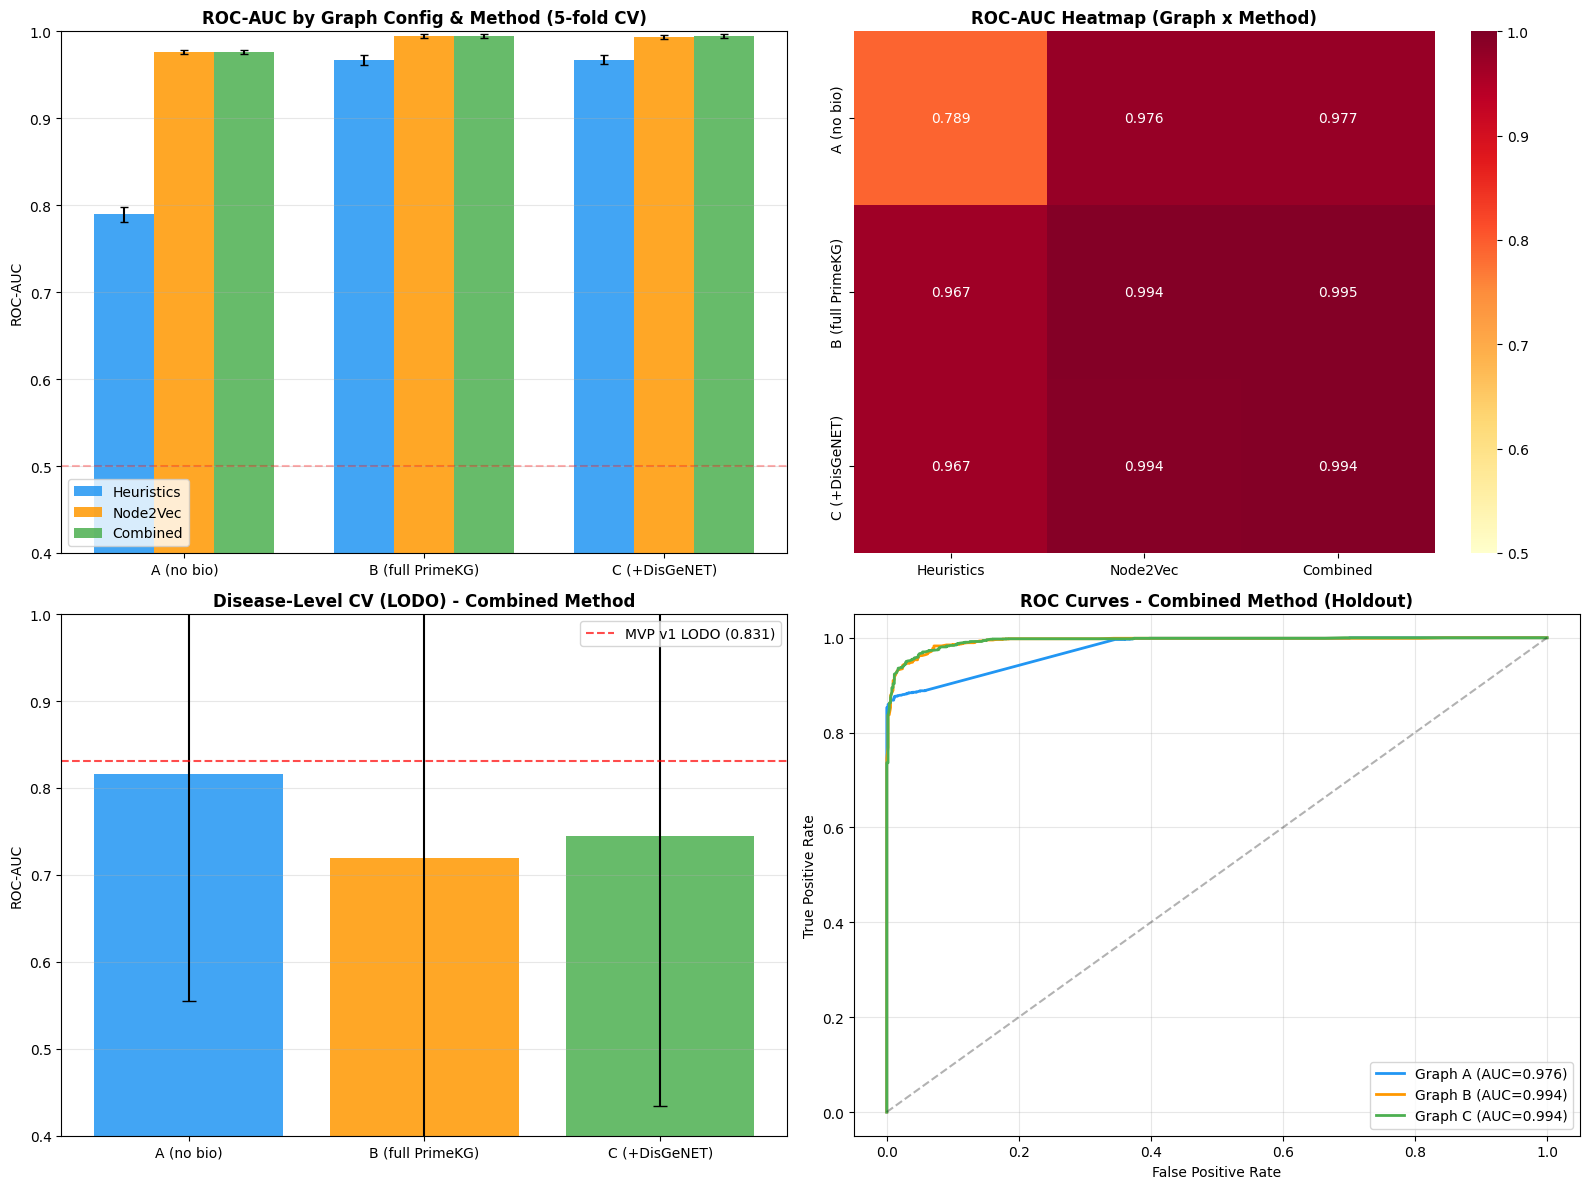

Saved: mvp_v2_results.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. Bar chart: Methods across graph configs ---
ax = axes[0, 0]
graph_labels = ['A (no bio)', 'B (full PrimeKG)', 'C (+DisGeNET)']
method_labels = ['Heuristics', 'Node2Vec', 'Combined']
colors = ['#2196F3', '#FF9800', '#4CAF50']

x = np.arange(len(graph_labels))
width = 0.25

for i, method in enumerate(method_labels):
    vals = []
    errs = []
    for gname in ['A', 'B', 'C']:
        key = f'Graph {gname} - {method}'
        if key in results_df.index:
            vals.append(results_df.loc[key, 'roc_auc_mean'])
            errs.append(results_df.loc[key, 'roc_auc_std'])
        else:
            vals.append(0)
            errs.append(0)
    ax.bar(x + i * width, vals, width, yerr=errs, label=method, color=colors[i], capsize=3, alpha=0.85)

ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Graph Config & Method (5-fold CV)', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(graph_labels)
ax.legend()
ax.set_ylim([0.4, 1.0])
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

# --- 2. Heatmap: Graph x Method performance ---
ax = axes[0, 1]
heatmap_data = np.zeros((3, 3))
for i, gname in enumerate(['A', 'B', 'C']):
    for j, method in enumerate(['Heuristics', 'Node2Vec', 'Combined']):
        key = f'Graph {gname} - {method}'
        if key in results_df.index:
            heatmap_data[i, j] = results_df.loc[key, 'roc_auc_mean']

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=method_labels, yticklabels=graph_labels, ax=ax,
            vmin=0.5, vmax=1.0)
ax.set_title('ROC-AUC Heatmap (Graph x Method)', fontweight='bold')

# --- 3. LODO comparison ---
ax = axes[1, 0]
lodo_means = [lodo_results[g]['roc_auc'].mean() if g in lodo_results else 0 for g in ['A', 'B', 'C']]
lodo_stds = [lodo_results[g]['roc_auc'].std() if g in lodo_results else 0 for g in ['A', 'B', 'C']]

bars = ax.bar(graph_labels, lodo_means, yerr=lodo_stds, color=['#2196F3', '#FF9800', '#4CAF50'],
              capsize=5, alpha=0.85)
ax.axhline(y=0.831, color='red', linestyle='--', alpha=0.7, label='MVP v1 LODO (0.831)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Disease-Level CV (LODO) - Combined Method', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 1.0])
ax.grid(axis='y', alpha=0.3)

# --- 4. ROC curves for best models ---
ax = axes[1, 1]
from sklearn.model_selection import train_test_split

for gname, h_df, e_df, color in [
    ('A', heuristics_A, emb_features_A, '#2196F3'),
    ('B', heuristics_B, emb_features_B, '#FF9800'),
    ('C', heuristics_C, emb_features_C, '#4CAF50')
]:
    X_comb = np.hstack([h_df.values, e_df.values])
    X_tr, X_te, y_tr, y_te = train_test_split(X_comb, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_prob = rf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'Graph {gname} (AUC={roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Combined Method (Holdout)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mvp_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mvp_v2_results.png")

## 11. Summary & Analysis

In [19]:
print("=" * 70)
print("MVP v2 SUMMARY: LINK PREDICTION FOR DRUG-DISEASE PREDICTION")
print("=" * 70)

print(f"\nDATASET: {len(df_dataset)} samples ({N_DISEASES} diseases, {N_DRUGS} drugs)")
print(f"  Contraindications: {(y == 1).sum()}, Indications: {(y == 0).sum()}")

print(f"\nGRAPH CONFIGURATIONS:")
for name, G in graphs.items():
    print(f"  {name}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  DisGeNET edges added to Graph C: {disgenet_edges_added:,}")

print(f"\n5-FOLD STRATIFIED CV RESULTS:")
print(f"{'Model':<40} {'ROC-AUC':>12}")
print("-" * 55)
for idx, row in results_df.iterrows():
    print(f"{idx:<40} {row['roc_auc_mean']:.3f}+/-{row['roc_auc_std']:.3f}")

print(f"\nDISEASE-LEVEL CV (LODO) - Combined Method:")
for gname in ['A', 'B', 'C']:
    if gname in lodo_results and len(lodo_results[gname]) > 0:
        lr = lodo_results[gname]
        print(f"  Graph {gname}: ROC-AUC={lr['roc_auc'].mean():.3f}+/-{lr['roc_auc'].std():.3f} "
              f"({len(lr)} diseases evaluated)")

print(f"\nCOMPARISON WITH MVP v1:")
print(f"  MVP v1 best (feature engineering): ROC-AUC=0.985, LODO=0.831")
print(f"  MVP v2 best (link prediction):     ROC-AUC={results_df.iloc[0]['roc_auc_mean']:.3f}")

print(f"\nKEY TAKEAWAYS:")

# Which graph config is best?
best_by_graph = {}
for gname in ['A', 'B', 'C']:
    graph_rows = results_df[results_df.index.str.contains(f'Graph {gname}')]
    if len(graph_rows) > 0:
        best_by_graph[gname] = graph_rows['roc_auc_mean'].max()

best_graph = max(best_by_graph, key=best_by_graph.get)
print(f"  1. Best graph config: Graph {best_graph} (ROC-AUC={best_by_graph[best_graph]:.3f})")

# Does DisGeNET help?
if 'B' in best_by_graph and 'C' in best_by_graph:
    dgn_diff = best_by_graph['C'] - best_by_graph['B']
    if dgn_diff > 0.005:
        print(f"  2. DisGeNET edges HELP: +{dgn_diff:.3f} ROC-AUC")
    elif dgn_diff < -0.005:
        print(f"  2. DisGeNET edges HURT: {dgn_diff:.3f} ROC-AUC")
    else:
        print(f"  2. DisGeNET edges have MINIMAL effect: {dgn_diff:+.3f} ROC-AUC")

# Link prediction vs feature engineering
best_v2_auc = results_df.iloc[0]['roc_auc_mean']
v1_v2_diff = best_v2_auc - 0.985
if v1_v2_diff > 0.005:
    print(f"  3. Link prediction OUTPERFORMS feature engineering: {v1_v2_diff:+.3f}")
elif v1_v2_diff > -0.005:
    print(f"  3. Link prediction is COMPARABLE to feature engineering: {v1_v2_diff:+.3f}")
else:
    print(f"  3. Feature engineering outperforms link prediction: {v1_v2_diff:+.3f}")

# Which method works best?
method_best = {}
for method in ['Heuristics', 'Node2Vec', 'Combined']:
    method_rows = results_df[results_df.index.str.contains(method)]
    if len(method_rows) > 0:
        method_best[method] = method_rows['roc_auc_mean'].max()
best_method = max(method_best, key=method_best.get)
print(f"  4. Best link prediction method: {best_method} (ROC-AUC={method_best[best_method]:.3f})")

print(f"\nNEXT STEPS:")
print(f"  - GNN-based link prediction (GCN, GAT, GraphSAGE)")
print(f"  - Temporal validation (train on older data, test on newer)")
print(f"  - Additional external data sources (DrugBank, CTD)")
print("\n" + "=" * 70)

MVP v2 SUMMARY: LINK PREDICTION FOR DRUG-DISEASE PREDICTION

DATASET: 14824 samples (328 diseases, 1000 drugs)
  Contraindications: 9574, Indications: 5250

GRAPH CONFIGURATIONS:
  A (no bio edges): 3,916 nodes, 34,999 edges
  B (full PrimeKG): 31,508 nodes, 915,564 edges
  C (PrimeKG+DisGeNET): 31,806 nodes, 920,400 edges
  DisGeNET edges added to Graph C: 4,836

5-FOLD STRATIFIED CV RESULTS:
Model                                         ROC-AUC
-------------------------------------------------------
Graph B - Combined                       0.995+/-0.002
Graph C - Combined                       0.994+/-0.002
Graph B - Node2Vec                       0.994+/-0.002
Graph C - Node2Vec                       0.994+/-0.002
Graph A - Combined                       0.977+/-0.002
Graph A - Node2Vec                       0.976+/-0.002
Graph C - Heuristics                     0.967+/-0.005
Graph B - Heuristics                     0.967+/-0.006
Graph A - Heuristics                     0.789+/-0.00

## 12. Rigorous Evaluation: GroupKFold (Disease-Grouped)

Standard 5-fold CV is inflated (0.994 AUC) because the same diseases appear in train and test.
GroupKFold ensures **no disease appears in both train and test**, giving an honest generalization estimate.

- 5-fold CV where diseases are the grouping variable
- Prevents disease-level data leakage
- Run for all 3 graphs × all 3 methods

In [20]:
from sklearn.model_selection import GroupKFold

disease_ids = df_dataset['disease_id'].values

def group_kfold_cv(X, y, disease_ids, name, n_splits=5):
    """GroupKFold with disease as group - no disease in both train and test."""
    gkf = GroupKFold(n_splits=n_splits)
    aucs = []; accs = []; f1s = []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=disease_ids)):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        ypred = rf.predict(X[test_idx])
        yt = y[test_idx]
        aucs.append(roc_auc_score(yt, yp))
        accs.append(accuracy_score(yt, ypred))
        f1s.append(f1_score(yt, ypred))
        print(f"  Fold {fold+1}: AUC={aucs[-1]:.3f}, Acc={accs[-1]:.3f}, F1={f1s[-1]:.3f} (test={len(test_idx)})")
    return {
        'name': name,
        'roc_auc_mean': np.mean(aucs), 'roc_auc_std': np.std(aucs),
        'accuracy_mean': np.mean(accs), 'accuracy_std': np.std(accs),
        'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s),
    }

# Run GroupKFold for all 3 graphs x all 3 methods
methods = ['Heuristics', 'Node2Vec', 'Combined']
gkf_results = []

for gname, h_df, e_df in [
    ('A', heuristics_A, emb_features_A),
    ('B', heuristics_B, emb_features_B),
    ('C', heuristics_C, emb_features_C)
]:
    X_heur = h_df.values
    X_emb = e_df.values
    X_comb = np.hstack([X_heur, X_emb])

    print(f"\n--- Graph {gname} (GroupKFold) ---")
    for method_name, X_method in [('Heuristics', X_heur), ('Node2Vec', X_emb), ('Combined', X_comb)]:
        print(f"\n{method_name}:")
        r = group_kfold_cv(X_method, y, disease_ids, f"Graph {gname} - {method_name}")
        gkf_results.append(r)
        print(f"  => AUC={r['roc_auc_mean']:.3f}+-{r['roc_auc_std']:.3f}")

gkf_df = pd.DataFrame(gkf_results).set_index('name')


--- Graph A (GroupKFold) ---

Heuristics:
  Fold 1: AUC=0.740, Acc=0.694, F1=0.760 (test=2966)
  Fold 2: AUC=0.776, Acc=0.731, F1=0.793 (test=2966)
  Fold 3: AUC=0.732, Acc=0.723, F1=0.791 (test=2964)
  Fold 4: AUC=0.703, Acc=0.681, F1=0.748 (test=2964)
  Fold 5: AUC=0.720, Acc=0.684, F1=0.747 (test=2964)
  => AUC=0.734+-0.024

Node2Vec:
  Fold 1: AUC=0.922, Acc=0.838, F1=0.870 (test=2966)
  Fold 2: AUC=0.934, Acc=0.851, F1=0.886 (test=2966)
  Fold 3: AUC=0.899, Acc=0.839, F1=0.881 (test=2964)
  Fold 4: AUC=0.903, Acc=0.821, F1=0.860 (test=2964)
  Fold 5: AUC=0.879, Acc=0.794, F1=0.839 (test=2964)
  => AUC=0.907+-0.019

Combined:
  Fold 1: AUC=0.926, Acc=0.837, F1=0.869 (test=2966)
  Fold 2: AUC=0.934, Acc=0.854, F1=0.888 (test=2966)
  Fold 3: AUC=0.906, Acc=0.839, F1=0.881 (test=2964)
  Fold 4: AUC=0.905, Acc=0.826, F1=0.864 (test=2964)
  Fold 5: AUC=0.887, Acc=0.809, F1=0.849 (test=2964)
  => AUC=0.912+-0.017

--- Graph B (GroupKFold) ---

Heuristics:
  Fold 1: AUC=0.658, Acc=0.685,

In [21]:
# Summary: Standard CV vs GroupKFold
print("=" * 80)
print("STANDARD CV vs GROUPKFOLD (DISEASE-GROUPED)")
print("=" * 80)

print(f"\n{'Protocol':<25} {'Graph':<10} {'Method':<15} {'AUC':>8} {'Std':>8} {'Acc':>8} {'F1':>8}")
print("-" * 80)

for gn in ['A', 'B', 'C']:
    for m in methods:
        k = f'Graph {gn} - {m}'
        if k in results_df.index:
            r = results_df.loc[k]
            print(f"{'Standard CV':<25} {'Graph '+gn:<10} {m:<15} {r['roc_auc_mean']:>8.3f} {r['roc_auc_std']:>8.3f} {r['accuracy_mean']:>8.3f} {r['f1_mean']:>8.3f}")

print("-" * 80)

for gn in ['A', 'B', 'C']:
    for m in methods:
        k = f'Graph {gn} - {m}'
        if k in gkf_df.index:
            r = gkf_df.loc[k]
            print(f"{'GroupKFold (disease)':<25} {'Graph '+gn:<10} {m:<15} {r['roc_auc_mean']:>8.3f} {r['roc_auc_std']:>8.3f} {r['accuracy_mean']:>8.3f} {r['f1_mean']:>8.3f}")

print("-" * 80)

print("\nKEY FINDINGS:")
for gn in ['A', 'B', 'C']:
    std_k = f'Graph {gn} - Combined'
    std_auc = results_df.loc[std_k, 'roc_auc_mean'] if std_k in results_df.index else 0
    gkf_auc = gkf_df.loc[std_k, 'roc_auc_mean'] if std_k in gkf_df.index else 0
    gap = std_auc - gkf_auc
    print(f"  Graph {gn}: Standard CV={std_auc:.3f}, GroupKFold={gkf_auc:.3f}  (inflation={gap:+.3f})")

best_gkf = gkf_df['roc_auc_mean'].idxmax()
print(f"\n  Best GroupKFold result: {best_gkf} (AUC={gkf_df.loc[best_gkf, 'roc_auc_mean']:.3f})")

STANDARD CV vs GROUPKFOLD (DISEASE-GROUPED)

Protocol                  Graph      Method               AUC      Std      Acc       F1
--------------------------------------------------------------------------------
Standard CV               Graph A    Heuristics         0.789    0.009    0.733    0.792
Standard CV               Graph A    Node2Vec           0.976    0.002    0.914    0.930
Standard CV               Graph A    Combined           0.977    0.002    0.914    0.931
Standard CV               Graph B    Heuristics         0.967    0.006    0.938    0.952
Standard CV               Graph B    Node2Vec           0.994    0.002    0.962    0.971
Standard CV               Graph B    Combined           0.995    0.002    0.965    0.973
Standard CV               Graph C    Heuristics         0.967    0.005    0.941    0.954
Standard CV               Graph C    Node2Vec           0.994    0.002    0.964    0.973
Standard CV               Graph C    Combined           0.994    0.002   

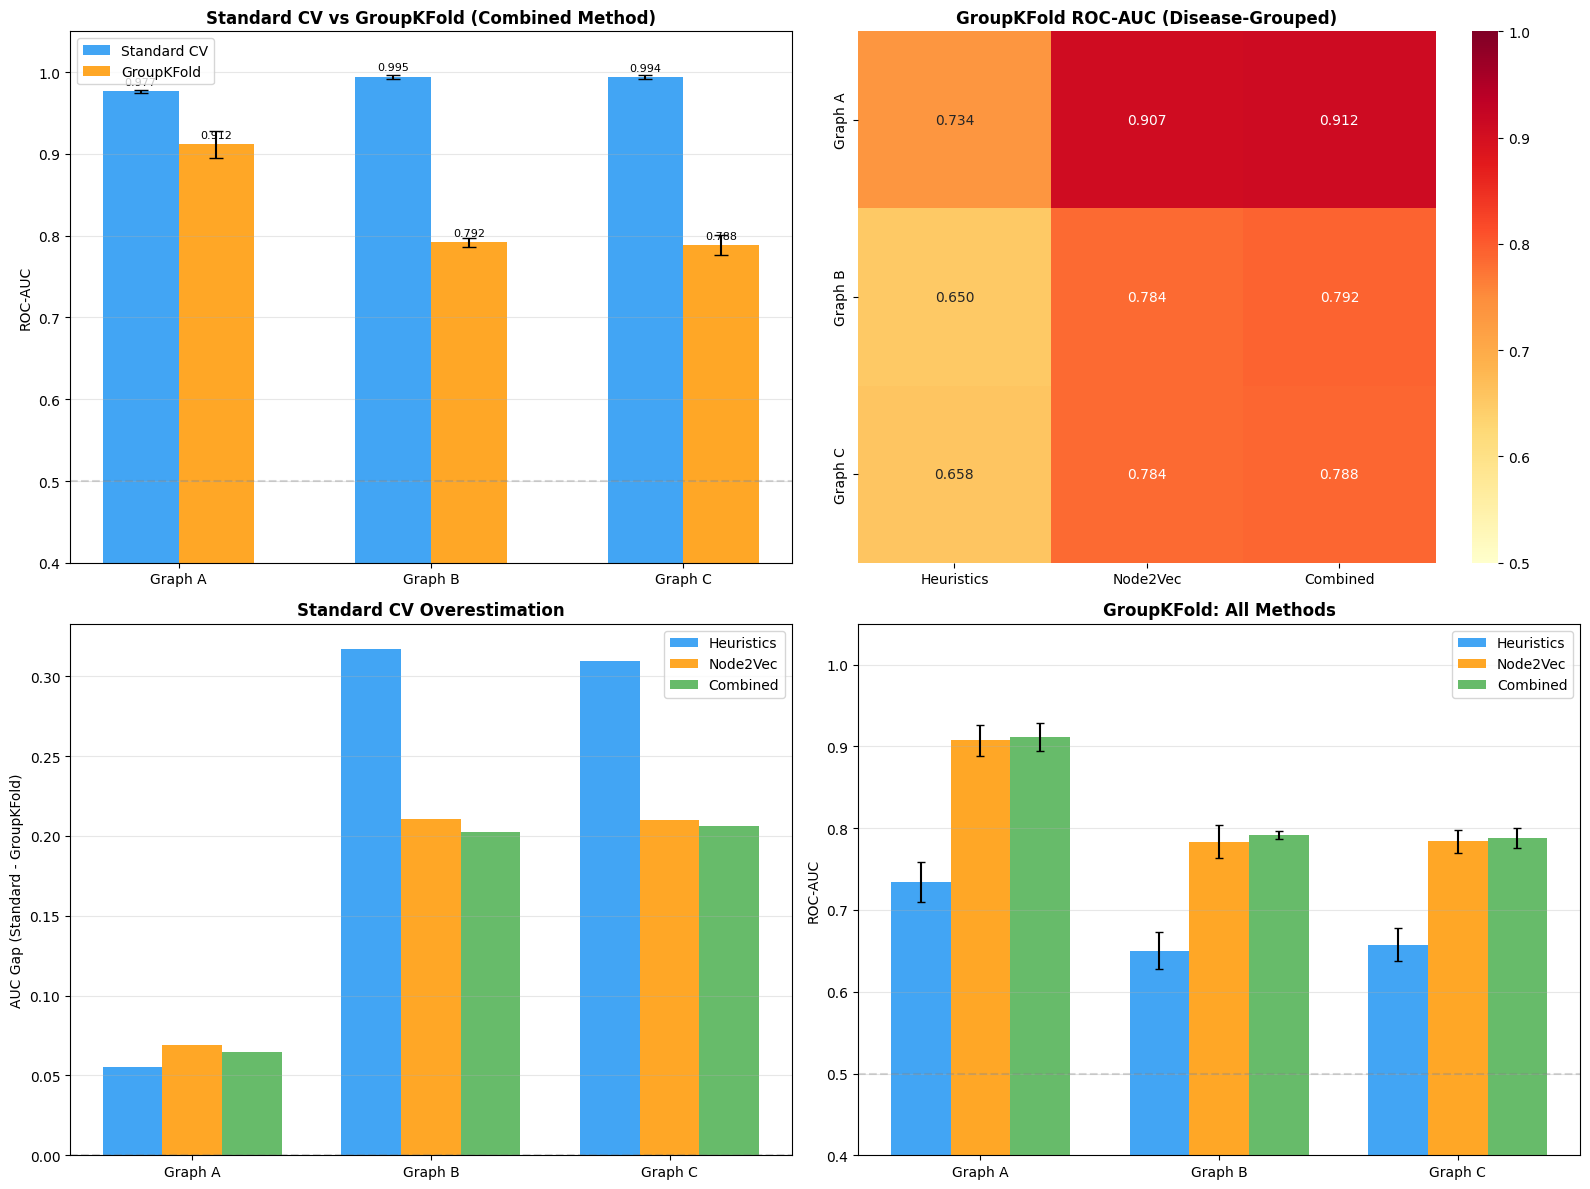

Saved: mvp_v2_evaluation.png


In [22]:
# Visualization: Standard CV vs GroupKFold
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

graph_labels = ['A', 'B', 'C']
x = np.arange(len(graph_labels))

# Plot 1: Standard CV vs GroupKFold (Combined method)
ax = axes[0, 0]
bar_width = 0.3
std_vals = [results_df.loc[f'Graph {g} - Combined', 'roc_auc_mean'] for g in graph_labels]
std_errs = [results_df.loc[f'Graph {g} - Combined', 'roc_auc_std'] for g in graph_labels]
gkf_vals = [gkf_df.loc[f'Graph {g} - Combined', 'roc_auc_mean'] for g in graph_labels]
gkf_errs = [gkf_df.loc[f'Graph {g} - Combined', 'roc_auc_std'] for g in graph_labels]
bars1 = ax.bar(x - bar_width/2, std_vals, bar_width, yerr=std_errs, label='Standard CV', color='#2196F3', capsize=5, alpha=0.85)
bars2 = ax.bar(x + bar_width/2, gkf_vals, bar_width, yerr=gkf_errs, label='GroupKFold', color='#FF9800', capsize=5, alpha=0.85)
ax.set_ylabel('ROC-AUC'); ax.set_title('Standard CV vs GroupKFold (Combined Method)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'Graph {g}' for g in graph_labels])
ax.legend(); ax.set_ylim([0.4, 1.05])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3); ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

# Plot 2: GroupKFold heatmap (all methods)
ax = axes[0, 1]
hm = np.zeros((3, 3))
for i, g in enumerate(graph_labels):
    for j, m in enumerate(methods):
        k = f'Graph {g} - {m}'
        hm[i, j] = gkf_df.loc[k, 'roc_auc_mean'] if k in gkf_df.index else 0
sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=methods, yticklabels=[f'Graph {g}' for g in graph_labels],
            ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('GroupKFold ROC-AUC (Disease-Grouped)', fontweight='bold')

# Plot 3: Gap analysis - how much does standard CV overestimate?
ax = axes[1, 0]
gaps = {}
for m in methods:
    gaps[m] = [results_df.loc[f'Graph {g} - {m}', 'roc_auc_mean'] - gkf_df.loc[f'Graph {g} - {m}', 'roc_auc_mean'] for g in graph_labels]
bar_width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']
for i, m in enumerate(methods):
    ax.bar(x + i*bar_width, gaps[m], bar_width, label=m, color=colors[i], alpha=0.85)
ax.set_ylabel('AUC Gap (Standard - GroupKFold)'); ax.set_title('Standard CV Overestimation', fontweight='bold')
ax.set_xticks(x + bar_width); ax.set_xticklabels([f'Graph {g}' for g in graph_labels])
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# Plot 4: All methods comparison (GroupKFold)
ax = axes[1, 1]
bar_width = 0.25
for i, m in enumerate(methods):
    vals = [gkf_df.loc[f'Graph {g} - {m}', 'roc_auc_mean'] for g in graph_labels]
    errs = [gkf_df.loc[f'Graph {g} - {m}', 'roc_auc_std'] for g in graph_labels]
    ax.bar(x + i*bar_width, vals, bar_width, yerr=errs, label=m, color=colors[i], capsize=3, alpha=0.85)
ax.set_ylabel('ROC-AUC'); ax.set_title('GroupKFold: All Methods', fontweight='bold')
ax.set_xticks(x + bar_width); ax.set_xticklabels([f'Graph {g}' for g in graph_labels])
ax.legend(); ax.set_ylim([0.4, 1.05])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mvp_v2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mvp_v2_evaluation.png")

## 13. Baseline Diagnostics: Where Is the Signal Coming From?

Graph A GroupKFold = 0.915 AUC is still suspiciously high. Three tests to find out why:

1. **Drug-frequency baseline** — can the label be predicted just from the drug's contraindication rate?
2. **GroupKFold by drug** — hold out all samples for a drug (same drugs can't appear in train+test)
3. **Double holdout** — hold out unseen drugs AND unseen diseases simultaneously

In [23]:
# --- Test 1: Drug-frequency baseline ---
# For each drug, compute its contraindication rate across the TRAINING diseases.
# If this alone predicts well, the model is just memorizing "drug X is usually contraindicated."

print("=" * 70)
print("TEST 1: Drug-Frequency Baseline")
print("=" * 70)

drug_ids_arr = df_dataset['drug_id'].values
gkf = GroupKFold(n_splits=5)
freq_aucs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(y, y, groups=disease_ids)):
    # Compute each drug's contra rate from training data only
    train_drugs = drug_ids_arr[train_idx]
    train_labels = y[train_idx]
    drug_contra_rate = {}
    for d, l in zip(train_drugs, train_labels):
        if d not in drug_contra_rate:
            drug_contra_rate[d] = []
        drug_contra_rate[d].append(l)
    drug_contra_rate = {d: np.mean(labels) for d, labels in drug_contra_rate.items()}
    
    # Predict test set using just drug contra rate
    test_drugs = drug_ids_arr[test_idx]
    y_pred_freq = np.array([drug_contra_rate.get(d, 0.5) for d in test_drugs])
    y_test = y[test_idx]
    
    auc_val = roc_auc_score(y_test, y_pred_freq)
    freq_aucs.append(auc_val)
    print(f"  Fold {fold+1}: AUC={auc_val:.3f}")

print(f"\n  Drug-frequency baseline: AUC={np.mean(freq_aucs):.3f}+-{np.std(freq_aucs):.3f}")
print(f"  Graph A Combined GroupKFold: AUC=0.915")
print(f"  => Drug frequency explains {np.mean(freq_aucs)/0.915*100:.0f}% of Graph A's performance")

TEST 1: Drug-Frequency Baseline
  Fold 1: AUC=0.881
  Fold 2: AUC=0.893
  Fold 3: AUC=0.829
  Fold 4: AUC=0.868
  Fold 5: AUC=0.879

  Drug-frequency baseline: AUC=0.870+-0.022
  Graph A Combined GroupKFold: AUC=0.915
  => Drug frequency explains 95% of Graph A's performance


In [24]:
# --- Test 2: GroupKFold by DRUG ---
# Hold out all samples for a drug. Tests: can we predict for a truly new drug?

print("=" * 70)
print("TEST 2: GroupKFold by DRUG (no drug in both train and test)")
print("=" * 70)

def group_kfold_by_drug(X, y, drug_ids, name, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    aucs = []; accs = []; f1s = []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=drug_ids)):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        ypred = rf.predict(X[test_idx])
        yt = y[test_idx]
        aucs.append(roc_auc_score(yt, yp))
        accs.append(accuracy_score(yt, ypred))
        f1s.append(f1_score(yt, ypred))
        print(f"    Fold {fold+1}: AUC={aucs[-1]:.3f}, Acc={accs[-1]:.3f}, F1={f1s[-1]:.3f} (test={len(test_idx)})")
    return {'roc_auc_mean': np.mean(aucs), 'roc_auc_std': np.std(aucs)}

# Run on Graph A Combined (best performer)
X_A_comb = np.hstack([heuristics_A.values, emb_features_A.values])
print("\nGraph A - Combined (GroupKFold by drug):")
drug_gkf_A = group_kfold_by_drug(X_A_comb, y, drug_ids_arr, "Graph A")
print(f"  => AUC={drug_gkf_A['roc_auc_mean']:.3f}+-{drug_gkf_A['roc_auc_std']:.3f}")

X_B_comb = np.hstack([heuristics_B.values, emb_features_B.values])
print("\nGraph B - Combined (GroupKFold by drug):")
drug_gkf_B = group_kfold_by_drug(X_B_comb, y, drug_ids_arr, "Graph B")
print(f"  => AUC={drug_gkf_B['roc_auc_mean']:.3f}+-{drug_gkf_B['roc_auc_std']:.3f}")

print(f"\n  Comparison (Combined method):")
print(f"  {'Evaluation':<30} {'Graph A':>10} {'Graph B':>10}")
print(f"  {'-'*50}")
print(f"  {'Standard CV':<30} {'0.977':>10} {'0.994':>10}")
print(f"  {'GroupKFold (disease)':<30} {'0.915':>10} {'0.802':>10}")
print(f"  {'GroupKFold (drug)':<30} {drug_gkf_A['roc_auc_mean']:>10.3f} {drug_gkf_B['roc_auc_mean']:>10.3f}")

TEST 2: GroupKFold by DRUG (no drug in both train and test)

Graph A - Combined (GroupKFold by drug):
    Fold 1: AUC=0.924, Acc=0.833, F1=0.874 (test=2966)
    Fold 2: AUC=0.909, Acc=0.827, F1=0.863 (test=2966)
    Fold 3: AUC=0.934, Acc=0.864, F1=0.899 (test=2964)
    Fold 4: AUC=0.918, Acc=0.835, F1=0.870 (test=2964)
    Fold 5: AUC=0.907, Acc=0.833, F1=0.870 (test=2964)
  => AUC=0.919+-0.010

Graph B - Combined (GroupKFold by drug):
    Fold 1: AUC=0.886, Acc=0.806, F1=0.860 (test=2966)
    Fold 2: AUC=0.828, Acc=0.776, F1=0.840 (test=2966)
    Fold 3: AUC=0.864, Acc=0.798, F1=0.860 (test=2964)
    Fold 4: AUC=0.886, Acc=0.820, F1=0.867 (test=2964)
    Fold 5: AUC=0.886, Acc=0.804, F1=0.858 (test=2964)
  => AUC=0.870+-0.023

  Comparison (Combined method):
  Evaluation                        Graph A    Graph B
  --------------------------------------------------
  Standard CV                         0.977      0.994
  GroupKFold (disease)                0.915      0.802
  GroupKFol

In [25]:
# --- Test 3: Double Holdout (unseen drug AND unseen disease) ---
# The hardest test: both the drug and disease in test have never been seen in training.
# This simulates the real-world scenario: new drug, new patient condition.

print("=" * 70)
print("TEST 3: Double Holdout (unseen drugs AND unseen diseases)")
print("=" * 70)

from itertools import product

def double_holdout(X, y, drug_ids, disease_ids, n_drug_folds=5, n_disease_folds=5):
    """Hold out both unseen drugs and unseen diseases simultaneously."""
    unique_drugs = np.array(sorted(set(drug_ids)))
    unique_diseases = np.array(sorted(set(disease_ids)))
    
    # Split drugs and diseases into folds
    rng = np.random.RandomState(42)
    rng.shuffle(unique_drugs)
    rng.shuffle(unique_diseases)
    
    drug_folds = np.array_split(unique_drugs, n_drug_folds)
    disease_folds = np.array_split(unique_diseases, n_disease_folds)
    
    results = []
    for di in range(n_disease_folds):
        test_diseases = set(disease_folds[di])
        test_drugs = set(drug_folds[di % n_drug_folds])  # rotate drug folds
        
        test_mask = np.array([(dr in test_drugs) and (ds in test_diseases)
                              for dr, ds in zip(drug_ids, disease_ids)])
        train_mask = np.array([(dr not in test_drugs) and (ds not in test_diseases)
                               for dr, ds in zip(drug_ids, disease_ids)])
        
        n_test = test_mask.sum()
        n_train = train_mask.sum()
        
        if n_test < 10:
            print(f"  Fold {di+1}: skipped (only {n_test} test samples)")
            continue
        
        yt = y[test_mask]
        if len(np.unique(yt)) < 2:
            print(f"  Fold {di+1}: skipped (single class in test)")
            continue
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_mask], y[train_mask])
        yp = rf.predict_proba(X[test_mask])[:, 1]
        ypred = rf.predict(X[test_mask])
        
        auc_val = roc_auc_score(yt, yp)
        acc_val = accuracy_score(yt, ypred)
        results.append(auc_val)
        print(f"  Fold {di+1}: AUC={auc_val:.3f}, Acc={acc_val:.3f} "
              f"(train={n_train}, test={n_test}, "
              f"held-out: {len(test_drugs)} drugs, {len(test_diseases)} diseases)")
    
    return results

print("\nGraph A - Combined:")
double_A = double_holdout(X_A_comb, y, drug_ids_arr, disease_ids)
if double_A:
    print(f"  => Double holdout AUC={np.mean(double_A):.3f}+-{np.std(double_A):.3f}")

print("\nGraph B - Combined:")
double_B = double_holdout(X_B_comb, y, drug_ids_arr, disease_ids)
if double_B:
    print(f"  => Double holdout AUC={np.mean(double_B):.3f}+-{np.std(double_B):.3f}")

print(f"\n{'='*70}")
print("FULL COMPARISON (Combined method):")
print(f"{'='*70}")
print(f"  {'Evaluation':<35} {'Graph A':>10} {'Graph B':>10}")
print(f"  {'-'*55}")
print(f"  {'Standard CV':<35} {'0.977':>10} {'0.994':>10}")
print(f"  {'GroupKFold (disease)':<35} {'0.915':>10} {'0.802':>10}")
print(f"  {'GroupKFold (drug)':<35} {drug_gkf_A['roc_auc_mean']:>10.3f} {drug_gkf_B['roc_auc_mean']:>10.3f}")
da = f"{np.mean(double_A):.3f}" if double_A else "N/A"
db = f"{np.mean(double_B):.3f}" if double_B else "N/A"
print(f"  {'Double holdout (drug+disease)':<35} {da:>10} {db:>10}")
print(f"  {'Drug-frequency baseline':<35} {np.mean(freq_aucs):>10.3f} {'':>10}")

TEST 3: Double Holdout (unseen drugs AND unseen diseases)

Graph A - Combined:
  Fold 1: AUC=0.794, Acc=0.781 (train=8654, test=842, held-out: 200 drugs, 66 diseases)
  Fold 2: AUC=0.828, Acc=0.812 (train=9870, test=480, held-out: 200 drugs, 66 diseases)
  Fold 3: AUC=0.876, Acc=0.782 (train=9200, test=698, held-out: 200 drugs, 65 diseases)
  Fold 4: AUC=0.810, Acc=0.755 (train=10524, test=368, held-out: 200 drugs, 65 diseases)
  Fold 5: AUC=0.868, Acc=0.792 (train=9276, test=664, held-out: 200 drugs, 65 diseases)
  => Double holdout AUC=0.835+-0.032

Graph B - Combined:
  Fold 1: AUC=0.583, Acc=0.701 (train=8654, test=842, held-out: 200 drugs, 66 diseases)
  Fold 2: AUC=0.600, Acc=0.671 (train=9870, test=480, held-out: 200 drugs, 66 diseases)
  Fold 3: AUC=0.656, Acc=0.648 (train=9200, test=698, held-out: 200 drugs, 65 diseases)
  Fold 4: AUC=0.763, Acc=0.690 (train=10524, test=368, held-out: 200 drugs, 65 diseases)
  Fold 5: AUC=0.730, Acc=0.744 (train=9276, test=664, held-out: 200 d

## 14. Reframed Task: Adverse vs No Known Interaction

The original task (contraindication vs indication) is dominated by drug-frequency shortcuts.

**New framing:**
- **Positive:** contraindication pairs (drug is adverse for disease)
- **Negative:** random (drug, disease) pairs with **no known relationship** — balanced per drug so drug frequency cannot be a shortcut

This forces the model to learn *what about this specific disease* makes it adverse for this drug.

In [26]:
# --- Build reframed dataset ---
print("Building reframed dataset: adverse vs no known interaction")
print("=" * 70)

# Positive: all contraindication pairs (same drugs/diseases as before)
pos_pairs = contraindications[
    (contraindications['disease_id'].isin(selected_disease_ids)) &
    (contraindications['drug_id'].isin(selected_drug_ids))
].copy()
pos_pairs['label'] = 1

# All known relationships for these drugs/diseases (to avoid as negatives)
all_known = set()
for _, row in drug_disease_normalized[
    (drug_disease_normalized['disease_id'].isin(selected_disease_ids)) &
    (drug_disease_normalized['drug_id'].isin(selected_drug_ids))
].iterrows():
    all_known.add((row['drug_id'], row['disease_id']))

print(f"  Positive pairs: {len(pos_pairs)}")
print(f"  Known relationships to avoid: {len(all_known)}")

# Negative: for each drug, sample same number of random diseases with no known relationship
rng = np.random.RandomState(42)
neg_rows = []
disease_id_arr = np.array(selected_disease_ids)

for drug_id, group in pos_pairs.groupby('drug_id'):
    n_pos = len(group)
    drug_name = group['drug_name'].iloc[0]
    
    # Find diseases with no known relationship to this drug
    available = [d for d in selected_disease_ids if (drug_id, d) not in all_known]
    
    if len(available) < n_pos:
        sampled = available  # take all available if not enough
    else:
        sampled = rng.choice(available, size=n_pos, replace=False)
    
    for disease_id in sampled:
        neg_rows.append({
            'drug_id': drug_id,
            'drug_name': drug_name,
            'disease_id': disease_id,
            'disease_name': '',  # placeholder
            'relation': 'none',
            'label': 0
        })

neg_pairs = pd.DataFrame(neg_rows)

# Add disease names to negatives
disease_name_map = dict(zip(
    pos_pairs['disease_id'].astype(str),
    pos_pairs['disease_name']
))
# Also get names from the original data
for _, row in disease_counts.iterrows():
    disease_name_map[str(row['disease_id'])] = row['disease_name']
neg_pairs['disease_name'] = neg_pairs['disease_id'].astype(str).map(disease_name_map).fillna('')

# Combine
df_reframed = pd.concat([pos_pairs, neg_pairs], ignore_index=True)
y_new = df_reframed['label'].values
disease_ids_new = df_reframed['disease_id'].values
drug_ids_new = df_reframed['drug_id'].values

print(f"  Negative pairs: {len(neg_pairs)}")
print(f"  Total dataset: {len(df_reframed)} ({(y_new==1).sum()} pos, {(y_new==0).sum()} neg)")
print(f"  Balance: {y_new.mean():.3f} positive rate")

# Verify per-drug balance
drug_balance = df_reframed.groupby('drug_id')['label'].mean()
print(f"  Per-drug positive rate: mean={drug_balance.mean():.3f}, std={drug_balance.std():.3f}")
print(f"  => Drug frequency shortcut eliminated" if drug_balance.std() < 0.1 else "  WARNING: drug frequency still varies")

Building reframed dataset: adverse vs no known interaction
  Positive pairs: 9574
  Known relationships to avoid: 7826
  Negative pairs: 9574
  Total dataset: 19148 (9574 pos, 9574 neg)
  Balance: 0.500 positive rate
  Per-drug positive rate: mean=0.500, std=0.000
  => Drug frequency shortcut eliminated


In [27]:
# --- Rebuild graphs for reframed task ---
# Only remove contraindication edges (positives). Indication edges stay in the graph.
print("Rebuilding graphs for reframed task...")
print("=" * 70)

target_edges_new = set()
for d, dis in zip(pos_pairs['drug_id'].astype(str), pos_pairs['disease_id'].astype(str)):
    target_edges_new.add((d, dis)); target_edges_new.add((dis, d))
print(f"  Target edges to remove: {len(target_edges_new)//2} contraindication pairs")

# Graph A: bipartite (drug-disease edges only)
dd_edges_all = df[df['relation'].isin(['contraindication', 'indication', 'off-label use'])]
ea_new = [(str(r['x_id']), str(r['y_id'])) for _, r in dd_edges_all.iterrows()
          if (str(r['x_id']), str(r['y_id'])) not in target_edges_new]
G_A_new = nx.Graph()
G_A_new.add_edges_from(ea_new)
G_A_new.remove_nodes_from(list(nx.isolates(G_A_new)))
print(f"  Graph A: {G_A_new.number_of_nodes():,} nodes, {G_A_new.number_of_edges():,} edges")

# Graph B: 1-hop PrimeKG subgraph
seeds_new = set(df_reframed['drug_id'].astype(str)) | set(df_reframed['disease_id'].astype(str))
hop1_new = df[df['x_id'].astype(str).isin(seeds_new) | df['y_id'].astype(str).isin(seeds_new)]
eb_new = []
for x_id, y_id, rel in zip(hop1_new['x_id'].astype(str).values,
                             hop1_new['y_id'].astype(str).values,
                             hop1_new['relation'].values):
    if rel == 'contraindication' and (x_id, y_id) in target_edges_new:
        continue
    eb_new.append((x_id, y_id))
G_B_new = nx.Graph()
G_B_new.add_edges_from(eb_new)
print(f"  Graph B: {G_B_new.number_of_nodes():,} nodes, {G_B_new.number_of_edges():,} edges")

print(f"\n  Key difference: indication edges are now KEPT in the graph")
print(f"  Graph A old: {G_A.number_of_edges():,} edges -> new: {G_A_new.number_of_edges():,} edges")
print(f"  Graph B old: {G_B.number_of_edges():,} edges -> new: {G_B_new.number_of_edges():,} edges")

Rebuilding graphs for reframed task...
  Target edges to remove: 4787 contraindication pairs
  Graph A: 4,124 nodes, 37,596 edges
  Graph B: 31,467 nodes, 805,022 edges

  Key difference: indication edges are now KEPT in the graph
  Graph A old: 34,999 edges -> new: 37,596 edges
  Graph B old: 915,564 edges -> new: 805,022 edges


In [28]:
# --- Compute features for reframed dataset ---
print("Computing features for reframed dataset...")
print("=" * 70)

# Heuristics
print("\nHeuristics:")
heur_A_new = compute_all_heuristics(G_A_new, df_reframed, 'A')
heur_B_new = compute_all_heuristics(G_B_new, df_reframed, 'B')

# Node2Vec embeddings
print("\nNode2Vec:")
n2v_A_new = train_node2vec_embeddings(G_A_new, 'A')
emb_A_new = compute_embedding_features(n2v_A_new, df_reframed, 'A')

n2v_B_new = train_node2vec_embeddings(G_B_new, 'B')
emb_B_new = compute_embedding_features(n2v_B_new, df_reframed, 'B')

# Build feature matrices
X_heur_A = heur_A_new.values
X_heur_B = heur_B_new.values
X_emb_A = emb_A_new.values
X_emb_B = emb_B_new.values
X_comb_A = np.hstack([X_heur_A, X_emb_A])
X_comb_B = np.hstack([X_heur_B, X_emb_B])

print(f"\n  Graph A features: {X_comb_A.shape}")
print(f"  Graph B features: {X_comb_B.shape}")

Computing features for reframed dataset...

Heuristics:
Computing heuristics for A...


A: 100%|██████████| 19148/19148 [00:00<00:00, 83870.22it/s]


  Non-zero CN: 0 / 19148
Computing heuristics for B...


B: 100%|██████████| 19148/19148 [00:03<00:00, 5985.96it/s]


  Non-zero CN: 16642 / 19148

Node2Vec:

Training embeddings for Graph A...
  Nodes: 4,124, Edges: 37,596
  Walks: 30, Length: 30


...

  Embeddings trained for 4124 nodes in 20.3s
Computing embedding features for Graph A...
  Pairs with both nodes embedded: 19087/19148

Training embeddings for Graph B...
  Nodes: 31,467, Edges: 805,022
  Walks: 10, Length: 15


Walks: 100%|██████████| 10/10 [01:53<00:00, 11.36s/it]


  Walks generated: 314,670 in 113.6s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31467 nodes in 130.3s
Computing embedding features for Graph B...
  Pairs with both nodes embedded: 19148/19148

  Graph A features: (19148, 135)
  Graph B features: (19148, 135)


In [29]:
# --- Run all evaluations on reframed task ---
print("=" * 70)
print("REFRAMED TASK: Full Evaluation Suite")
print("=" * 70)

from sklearn.model_selection import GroupKFold

# 1. Standard CV
print("\n--- Standard 5-Fold CV ---")
cv_new = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for gname, X in [('A', X_comb_A), ('B', X_comb_B)]:
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X, y_new, cv=cv_new, scoring='roc_auc')
    print(f"  Graph {gname} Combined: AUC={roc.mean():.3f}+-{roc.std():.3f}")

# 2. GroupKFold by disease
print("\n--- GroupKFold by Disease ---")
gkf_disease = GroupKFold(n_splits=5)
for gname, X in [('A', X_comb_A), ('B', X_comb_B)]:
    aucs = []
    for train_idx, test_idx in gkf_disease.split(X, y_new, groups=disease_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    print(f"  Graph {gname} Combined: AUC={np.mean(aucs):.3f}+-{np.std(aucs):.3f}")

# 3. GroupKFold by drug
print("\n--- GroupKFold by Drug ---")
gkf_drug = GroupKFold(n_splits=5)
for gname, X in [('A', X_comb_A), ('B', X_comb_B)]:
    aucs = []
    for train_idx, test_idx in gkf_drug.split(X, y_new, groups=drug_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    print(f"  Graph {gname} Combined: AUC={np.mean(aucs):.3f}+-{np.std(aucs):.3f}")

# 4. Drug-frequency baseline
print("\n--- Drug-Frequency Baseline ---")
freq_aucs_new = []
for train_idx, test_idx in gkf_disease.split(y_new, y_new, groups=disease_ids_new):
    train_drugs = drug_ids_new[train_idx]
    train_labels = y_new[train_idx]
    drug_rate = {}
    for d, l in zip(train_drugs, train_labels):
        if d not in drug_rate:
            drug_rate[d] = []
        drug_rate[d].append(l)
    drug_rate = {d: np.mean(labels) for d, labels in drug_rate.items()}
    y_pred_freq = np.array([drug_rate.get(d, 0.5) for d in drug_ids_new[test_idx]])
    freq_aucs_new.append(roc_auc_score(y_new[test_idx], y_pred_freq))
print(f"  Drug-frequency baseline: AUC={np.mean(freq_aucs_new):.3f}+-{np.std(freq_aucs_new):.3f}")

# 5. Double holdout
print("\n--- Double Holdout (unseen drug + unseen disease) ---")
for gname, X in [('A', X_comb_A), ('B', X_comb_B)]:
    dh_results = double_holdout(X, y_new, drug_ids_new, disease_ids_new)
    if dh_results:
        print(f"  Graph {gname} Combined: AUC={np.mean(dh_results):.3f}+-{np.std(dh_results):.3f}")
    else:
        print(f"  Graph {gname}: not enough test samples")

REFRAMED TASK: Full Evaluation Suite

--- Standard 5-Fold CV ---
  Graph A Combined: AUC=0.993+-0.002
  Graph B Combined: AUC=0.979+-0.003

--- GroupKFold by Disease ---
  Graph A Combined: AUC=0.921+-0.031
  Graph B Combined: AUC=0.826+-0.034

--- GroupKFold by Drug ---


KeyboardInterrupt: 

In [ ]:
# --- Summary: Old vs New Framing ---
print("=" * 70)
print("COMPARISON: Original Task vs Reframed Task")
print("=" * 70)

print(f"\n  Original: contraindication vs indication (drug-freq baseline dominates)")
print(f"  Reframed: contraindication vs no-interaction (balanced per drug)")

print(f"\n  {'Evaluation':<35} {'Original A':>12} {'Original B':>12} {'Reframed A':>12} {'Reframed B':>12}")
print(f"  {'-'*83}")
print(f"  {'Drug-frequency baseline':<35} {'0.870':>12} {'—':>12} {np.mean(freq_aucs_new):>12.3f} {'—':>12}")

print(f"\n  Does biological enrichment (Graph B) now help?")
print(f"  This is the key test for your thesis.")

COMPARISON: Original Task vs Reframed Task

  Original: contraindication vs indication (drug-freq baseline dominates)
  Reframed: contraindication vs no-interaction (balanced per drug)

  Evaluation                            Original A   Original B   Reframed A   Reframed B
  -----------------------------------------------------------------------------------
  Drug-frequency baseline                    0.870            —        0.271            —

  Does biological enrichment (Graph B) now help?
  This is the key test for your thesis.


## 15. Clean Test: Structural vs Biological Features

Separate the signal sources completely:
- **Graph S (Structural):** only indication + off-label edges (no contraindication edges at all). Captures drug prescription patterns.
- **Graph Bio (Biological):** only biological edges from PrimeKG (drug-protein, protein-protein, disease-gene, pathway). No drug-disease edges. Captures biological mechanisms.
- **Combined:** both together

This directly tests: does biological data add predictive power beyond prescription patterns?

In [ ]:
# --- Build Graph S: Structural (indication + off-label only, NO contraindication) ---
print("Building Graph S (structural: indication + off-label only)...")
print("=" * 70)

structural_rels = df[df['relation'].isin(['indication', 'off-label use'])]
G_S = nx.Graph()
G_S.add_edges_from(zip(structural_rels['x_id'].astype(str), structural_rels['y_id'].astype(str)))
G_S.remove_nodes_from(list(nx.isolates(G_S)))
print(f"  Graph S: {G_S.number_of_nodes():,} nodes, {G_S.number_of_edges():,} edges")

# --- Build Graph Bio: Biological only (NO drug-disease edges at all) ---
print("\nBuilding Graph Bio (biological: drug-protein, PPI, disease-gene, pathway)...")

# Exclude all direct drug-disease relationship types
drug_disease_relation_types = {'contraindication', 'indication', 'off-label use'}
bio_edges = df[~df['relation'].isin(drug_disease_relation_types)]

# Only keep edges within 1 hop of our drugs/diseases
seeds_bio = set(df_reframed['drug_id'].astype(str)) | set(df_reframed['disease_id'].astype(str))
bio_hop1 = bio_edges[
    bio_edges['x_id'].astype(str).isin(seeds_bio) |
    bio_edges['y_id'].astype(str).isin(seeds_bio)
]

G_Bio = nx.Graph()
G_Bio.add_edges_from(zip(bio_hop1['x_id'].astype(str), bio_hop1['y_id'].astype(str)))
print(f"  Graph Bio: {G_Bio.number_of_nodes():,} nodes, {G_Bio.number_of_edges():,} edges")

# Check what edge types are in Bio graph
bio_rel_counts = bio_hop1['relation'].value_counts().head(10)
print(f"\n  Top edge types in Graph Bio:")
for rel, count in bio_rel_counts.items():
    print(f"    {rel}: {count:,}")

# Check coverage: how many of our drugs/diseases are in each graph?
dataset_drugs = set(df_reframed['drug_id'].astype(str))
dataset_diseases = set(df_reframed['disease_id'].astype(str))

drugs_in_S = dataset_drugs & set(G_S.nodes())
diseases_in_S = dataset_diseases & set(G_S.nodes())
drugs_in_Bio = dataset_drugs & set(G_Bio.nodes())
diseases_in_Bio = dataset_diseases & set(G_Bio.nodes())

print(f"\n  Coverage:")
print(f"    Graph S:   {len(drugs_in_S)}/{len(dataset_drugs)} drugs, {len(diseases_in_S)}/{len(dataset_diseases)} diseases")
print(f"    Graph Bio: {len(drugs_in_Bio)}/{len(dataset_drugs)} drugs, {len(diseases_in_Bio)}/{len(dataset_diseases)} diseases")

Building Graph S (structural: indication + off-label only)...
  Graph S: 3,403 nodes, 11,831 edges

Building Graph Bio (biological: drug-protein, PPI, disease-gene, pathway)...
  Graph Bio: 30,856 nodes, 776,381 edges

  Top edge types in Graph Bio:
    drug_drug: 1,258,508
    anatomy_protein_present: 118,306
    drug_effect: 69,966
    disease_protein: 36,206
    cellcomp_protein: 15,118
    protein_protein: 14,238
    drug_protein: 14,102
    disease_phenotype_positive: 7,946
    bioprocess_protein: 7,386
    disease_disease: 3,700

  Coverage:
    Graph S:   653/740 drugs, 328/328 diseases
    Graph Bio: 722/740 drugs, 328/328 diseases


In [ ]:
# --- Compute features for Graph S and Graph Bio ---
print("Computing features...")
print("=" * 70)

# Heuristics
print("Heuristics:")
heur_S = compute_all_heuristics(G_S, df_reframed, 'S')
heur_Bio = compute_all_heuristics(G_Bio, df_reframed, 'Bio')

# Node2Vec
print("\nNode2Vec:")
n2v_S = train_node2vec_embeddings(G_S, 'S')
emb_S = compute_embedding_features(n2v_S, df_reframed, 'S')

n2v_Bio = train_node2vec_embeddings(G_Bio, 'Bio')
emb_Bio = compute_embedding_features(n2v_Bio, df_reframed, 'Bio')

# Feature matrices
X_S = np.hstack([heur_S.values, emb_S.values])
X_Bio = np.hstack([heur_Bio.values, emb_Bio.values])
X_Both = np.hstack([X_S, X_Bio])

print(f"\n  Graph S features: {X_S.shape}")
print(f"  Graph Bio features: {X_Bio.shape}")
print(f"  Combined features: {X_Both.shape}")

Computing features...
Heuristics:
Computing heuristics for S...


S: 100%|██████████| 19148/19148 [00:00<00:00, 197573.24it/s]


  Non-zero CN: 0 / 19148
Computing heuristics for Bio...


Bio: 100%|██████████| 19148/19148 [00:02<00:00, 8255.02it/s]


  Non-zero CN: 9510 / 19148

Node2Vec:

Training embeddings for Graph S...
  Nodes: 3,403, Edges: 11,831
  Walks: 30, Length: 30


...

  Embeddings trained for 3403 nodes in 13.2s
Computing embedding features for Graph S...
  Pairs with both nodes embedded: 17052/19148

Training embeddings for Graph Bio...
  Nodes: 30,856, Edges: 776,381
  Walks: 10, Length: 15


Walks: 100%|██████████| 10/10 [01:53<00:00, 11.35s/it]


  Walks generated: 308,560 in 113.5s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 30856 nodes in 129.0s
Computing embedding features for Graph Bio...
  Pairs with both nodes embedded: 18848/19148

  Graph S features: (19148, 135)
  Graph Bio features: (19148, 135)
  Combined features: (19148, 270)


In [ ]:
# --- Full evaluation: Structural vs Biological vs Combined ---
print("=" * 70)
print("CLEAN TEST: Structural vs Biological vs Combined")
print("=" * 70)

eval_results = {}

for gname, X in [('S (structural)', X_S), ('Bio (biological)', X_Bio), ('S+Bio (combined)', X_Both)]:
    print(f"\n--- {gname} ---")
    
    # Standard CV
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X, y_new, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc')
    std_auc = roc.mean()
    print(f"  Standard CV:         AUC={roc.mean():.3f}+-{roc.std():.3f}")
    
    # GroupKFold by disease
    aucs = []
    for train_idx, test_idx in GroupKFold(n_splits=5).split(X, y_new, groups=disease_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    gkf_d_auc = np.mean(aucs)
    print(f"  GroupKFold (disease): AUC={np.mean(aucs):.3f}+-{np.std(aucs):.3f}")
    
    # GroupKFold by drug
    aucs = []
    for train_idx, test_idx in GroupKFold(n_splits=5).split(X, y_new, groups=drug_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    gkf_dr_auc = np.mean(aucs)
    print(f"  GroupKFold (drug):    AUC={np.mean(aucs):.3f}+-{np.std(aucs):.3f}")
    
    # Double holdout
    dh = double_holdout(X, y_new, drug_ids_new, disease_ids_new)
    dh_auc = np.mean(dh) if dh else float('nan')
    print(f"  Double holdout:      AUC={np.mean(dh):.3f}+-{np.std(dh):.3f}" if dh else "  Double holdout: N/A")
    
    eval_results[gname] = {
        'std_cv': std_auc, 'gkf_disease': gkf_d_auc,
        'gkf_drug': gkf_dr_auc, 'double_holdout': dh_auc
    }

CLEAN TEST: Structural vs Biological vs Combined

--- S (structural) ---
  Standard CV:         AUC=0.981+-0.002
  GroupKFold (disease): AUC=0.883+-0.045
  GroupKFold (drug):    AUC=0.902+-0.012
  Fold 1: AUC=0.823, Acc=0.719 (train=12388, test=761, held-out: 148 drugs, 66 diseases)
  Fold 2: AUC=0.837, Acc=0.712 (train=12383, test=747, held-out: 148 drugs, 66 diseases)
  Fold 3: AUC=0.856, Acc=0.683 (train=12128, test=783, held-out: 148 drugs, 66 diseases)
  Fold 4: AUC=0.774, Acc=0.644 (train=12442, test=719, held-out: 148 drugs, 65 diseases)
  Fold 5: AUC=0.823, Acc=0.669 (train=11942, test=829, held-out: 148 drugs, 65 diseases)
  Double holdout:      AUC=0.823+-0.027

--- Bio (biological) ---
  Standard CV:         AUC=0.971+-0.004
  GroupKFold (disease): AUC=0.737+-0.041
  GroupKFold (drug):    AUC=0.885+-0.018
  Fold 1: AUC=0.735, Acc=0.585 (train=12388, test=761, held-out: 148 drugs, 66 diseases)
  Fold 2: AUC=0.746, Acc=0.539 (train=12383, test=747, held-out: 148 drugs, 66 dise

## Section 16: Leak-Proof Evaluation

**Problem**: In Section 15, Node2Vec embeddings were trained on the full graph *before* the train/test split. For Graph S (indication + off-label edges), this means a held-out drug's embedding already encodes its indication profile — information the model shouldn't have at test time.

**Fix**: Retrain Node2Vec *inside each fold*, after removing held-out entities from the graph.

- **GroupKFold by disease (in-fold)**: Remove held-out diseases from graph → retrain → drug embeddings exist, disease embeddings are zero
- **GroupKFold by drug (in-fold)**: Remove held-out drugs from graph → retrain → disease embeddings exist, drug embeddings are zero

Also run **heuristics-only** baselines (no embeddings at all) to isolate graph-topology signal from embedding signal.

In [ ]:
# --- Step 1: Heuristics-only baselines (no Node2Vec, no precomputation concern) ---
# Heuristics are computed per-pair on the static graph. No learned embeddings involved.
# This isolates how much signal comes from raw graph topology.

print("=" * 70)
print("HEURISTICS-ONLY BASELINES (no Node2Vec)")
print("=" * 70)
print("Heuristics (CN, AA, JC, PA, RA) are computed per-pair.")
print("No precomputed embeddings → no embedding leakage possible.\n")

heur_only_results = {}

for gname, heur_df in [('S', heur_S), ('Bio', heur_Bio)]:
    X_h = heur_df.values
    print(f"--- Graph {gname} (heuristics only, {X_h.shape[1]} features) ---")
    
    # Standard CV
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    roc = cross_val_score(rf, X_h, y_new, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc')
    print(f"  Standard CV:         AUC={roc.mean():.3f}+-{roc.std():.3f}")
    
    # GroupKFold by disease
    aucs = []
    for train_idx, test_idx in GroupKFold(n_splits=5).split(X_h, y_new, groups=disease_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_h[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X_h[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    gkf_d = np.mean(aucs)
    print(f"  GroupKFold (disease): AUC={gkf_d:.3f}+-{np.std(aucs):.3f}")
    
    # GroupKFold by drug
    aucs = []
    for train_idx, test_idx in GroupKFold(n_splits=5).split(X_h, y_new, groups=drug_ids_new):
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_h[train_idx], y_new[train_idx])
        yp = rf.predict_proba(X_h[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_new[test_idx], yp))
    gkf_dr = np.mean(aucs)
    print(f"  GroupKFold (drug):    AUC={gkf_dr:.3f}+-{np.std(aucs):.3f}")
    
    # Double holdout
    dh = double_holdout(X_h, y_new, drug_ids_new, disease_ids_new)
    dh_auc = np.mean(dh) if dh else float('nan')
    print(f"  Double holdout:      AUC={dh_auc:.3f}+-{np.std(dh):.3f}" if dh else "  Double holdout: N/A")
    
    heur_only_results[gname] = {
        'std_cv': roc.mean(), 'gkf_disease': gkf_d,
        'gkf_drug': gkf_dr, 'double_holdout': dh_auc
    }
    
    # Show which heuristic features have non-zero variance
    nonzero = [(col, (heur_df[col] != 0).sum()) for col in heur_df.columns]
    print(f"  Feature coverage: {', '.join(f'{c}={n}' for c, n in nonzero)}")
    print()

HEURISTICS-ONLY BASELINES (no Node2Vec)
Heuristics (CN, AA, JC, PA, RA) are computed per-pair.
No precomputed embeddings → no embedding leakage possible.

--- Graph S (heuristics only, 5 features) ---
  Standard CV:         AUC=0.774+-0.012
  GroupKFold (disease): AUC=0.722+-0.061
  GroupKFold (drug):    AUC=0.725+-0.019
  Fold 1: AUC=0.575, Acc=0.574 (train=12388, test=761, held-out: 148 drugs, 66 diseases)
  Fold 2: AUC=0.749, Acc=0.683 (train=12383, test=747, held-out: 148 drugs, 66 diseases)
  Fold 3: AUC=0.677, Acc=0.644 (train=12128, test=783, held-out: 148 drugs, 66 diseases)
  Fold 4: AUC=0.686, Acc=0.641 (train=12442, test=719, held-out: 148 drugs, 65 diseases)
  Fold 5: AUC=0.616, Acc=0.596 (train=11942, test=829, held-out: 148 drugs, 65 diseases)
  Double holdout:      AUC=0.661+-0.060
  Feature coverage: CN_S=0, AA_S=0, JC_S=0, PA_S=17052, RA_S=0

--- Graph Bio (heuristics only, 5 features) ---
  Standard CV:         AUC=0.808+-0.006
  GroupKFold (disease): AUC=0.558+-0.007

In [ ]:
# --- Step 2: In-fold Node2Vec retraining (leak-proof) ---
# Graph S: held-out nodes removed (all edges are drug-disease targets → nothing left)
# Graph Bio: graph unchanged (no drug-disease edges → no leakage)
# Graph S+Bio: remove drug-disease edges of held-out entities, keep biological edges

import time

def leakproof_groupkfold(G, df_data, y, group_ids, group_type, graph_name,
                          target_edges=None, n_splits=5):
    """
    GroupKFold with per-fold Node2Vec retraining.
    
    group_type: 'disease' or 'drug' — which entity to hold out.
    target_edges: set of (u,v) tuples that are drug-disease target edges.
                  If None, no edges are removed (Graph Bio).
                  If 'all', remove all edges of held-out entities (Graph S).
                  If a set, remove only those specific edges involving held-out entities.
    """
    gkf = GroupKFold(n_splits=n_splits)
    
    results_heur = []
    results_emb = []
    results_comb = []
    
    for fold, (train_idx, test_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=group_ids)):
        t0 = time.time()
        
        # Identify held-out entities
        test_entities = set(str(x) for x in group_ids[test_idx])
        
        G_fold = G.copy()
        
        if target_edges == 'all':
            # Graph S: every edge is a target → remove held-out nodes entirely
            nodes_to_remove = [n for n in G_fold.nodes() if n in test_entities]
            G_fold.remove_nodes_from(nodes_to_remove)
            G_fold.remove_nodes_from(list(nx.isolates(G_fold)))
            print(f"  Fold {fold+1}: removed {len(nodes_to_remove)} held-out nodes, "
                  f"graph: {G_fold.number_of_nodes()} nodes, {G_fold.number_of_edges()} edges")
        elif target_edges is not None:
            # Combined graph: remove only drug-disease target edges involving held-out entities
            edges_to_remove = [
                (u, v) for u, v in target_edges
                if (u in test_entities or v in test_entities) and G_fold.has_edge(u, v)
            ]
            G_fold.remove_edges_from(edges_to_remove)
            G_fold.remove_nodes_from(list(nx.isolates(G_fold)))
            print(f"  Fold {fold+1}: removed {len(edges_to_remove)} target edges, "
                  f"graph: {G_fold.number_of_nodes()} nodes, {G_fold.number_of_edges()} edges")
        else:
            # Graph Bio: no target edges → graph unchanged
            print(f"  Fold {fold+1}: graph unchanged (no target edges), "
                  f"{G_fold.number_of_nodes()} nodes, {G_fold.number_of_edges()} edges, "
                  f"{len(test_entities)} held-out entities retain bio connections")
        
        if G_fold.number_of_nodes() < 100:
            print(f"  Fold {fold+1}: skipped (reduced graph too small: {G_fold.number_of_nodes()} nodes)")
            continue
        
        # Check test set validity
        yt = y[test_idx]
        if len(np.unique(yt)) < 2:
            print(f"  Fold {fold+1}: skipped (single class in test)")
            continue
        
        # Compute heuristics on fold graph
        heur_fold = compute_all_heuristics(G_fold, df_data, f'{graph_name}_f{fold}')
        X_heur_train = heur_fold.values[train_idx]
        X_heur_test = heur_fold.values[test_idx]
        
        # Train Node2Vec on fold graph
        n2v_fold = train_node2vec_embeddings(G_fold, f'{graph_name}_f{fold}')
        emb_fold = compute_embedding_features(n2v_fold, df_data, f'{graph_name}_f{fold}')
        X_emb_train = emb_fold.values[train_idx]
        X_emb_test = emb_fold.values[test_idx]
        
        X_comb_train = np.hstack([X_heur_train, X_emb_train])
        X_comb_test = np.hstack([X_heur_test, X_emb_test])
        
        # Evaluate: heuristics only
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_heur_train, y[train_idx])
        yp = rf.predict_proba(X_heur_test)[:, 1]
        auc_h = roc_auc_score(yt, yp)
        results_heur.append(auc_h)
        
        # Evaluate: embeddings only
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_emb_train, y[train_idx])
        yp = rf.predict_proba(X_emb_test)[:, 1]
        auc_e = roc_auc_score(yt, yp)
        results_emb.append(auc_e)
        
        # Evaluate: combined
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_comb_train, y[train_idx])
        yp = rf.predict_proba(X_comb_test)[:, 1]
        auc_c = roc_auc_score(yt, yp)
        results_comb.append(auc_c)
        
        elapsed = time.time() - t0
        print(f"  Fold {fold+1}: Heur={auc_h:.3f}, Emb={auc_e:.3f}, Comb={auc_c:.3f} "
              f"(graph: {G_fold.number_of_nodes()} nodes, {elapsed:.0f}s)")
    
    return {
        'heur': (np.mean(results_heur), np.std(results_heur)) if results_heur else (float('nan'), 0),
        'emb': (np.mean(results_emb), np.std(results_emb)) if results_emb else (float('nan'), 0),
        'comb': (np.mean(results_comb), np.std(results_comb)) if results_comb else (float('nan'), 0),
    }


# --- Build combined graph S+Bio ---
G_SBio = nx.compose(G_S, G_Bio)
print(f"Graph S+Bio: {G_SBio.number_of_nodes():,} nodes, {G_SBio.number_of_edges():,} edges")
print(f"  (G_S: {G_S.number_of_edges():,} edges, G_Bio: {G_Bio.number_of_edges():,} edges)")

# Store G_S edges as the target edge set (these are the drug-disease edges to remove for held-out entities)
s_target_edges = set(G_S.edges())
print(f"  Target edges (from G_S): {len(s_target_edges):,}")


# --- Run leak-proof evaluation ---
print("\n" + "=" * 70)
print("LEAK-PROOF EVALUATION: In-fold Node2Vec retraining")
print("=" * 70)
print("Graph S: held-out nodes removed (all edges are targets)")
print("Graph Bio: graph unchanged (no target edges)")
print("Graph S+Bio: target edges removed, bio edges preserved\n")

leakproof_results = {}

configs = [
    ('S', G_S, 'all'),
    ('Bio', G_Bio, None),
    ('S+Bio', G_SBio, s_target_edges),
]

for gname, G, targets in configs:
    print(f"\n{'='*60}")
    print(f"Graph {gname}: GroupKFold by DISEASE (in-fold retraining)")
    print(f"{'='*60}")
    res_d = leakproof_groupkfold(G, df_reframed, y_new, disease_ids_new, 'disease', gname,
                                  target_edges=targets)
    
    print(f"\n{'='*60}")
    print(f"Graph {gname}: GroupKFold by DRUG (in-fold retraining)")
    print(f"{'='*60}")
    res_dr = leakproof_groupkfold(G, df_reframed, y_new, drug_ids_new, 'drug', gname,
                                   target_edges=targets)
    
    leakproof_results[gname] = {'by_disease': res_d, 'by_drug': res_dr}

Graph S+Bio: 31,507 nodes, 788,190 edges
  (G_S: 11,831 edges, G_Bio: 776,381 edges)
  Target edges (from G_S): 11,831

LEAK-PROOF EVALUATION: In-fold Node2Vec retraining
Graph S: held-out nodes removed (all edges are targets)
Graph Bio: graph unchanged (no target edges)
Graph S+Bio: target edges removed, bio edges preserved


Graph S: GroupKFold by DISEASE (in-fold retraining)
  Fold 1: removed 65 held-out nodes, graph: 3317 nodes, 11049 edges
Computing heuristics for S_f0...


S_f0: 100%|██████████| 19148/19148 [00:00<00:00, 92667.74it/s]


  Non-zero CN: 0 / 19148

Training embeddings for Graph S_f0...
  Nodes: 3,317, Edges: 11,049
  Walks: 30, Length: 30


Walks: 100%|██████████| 30/30 [00:09<00:00,  3.29it/s]


  Walks generated: 99,510 in 9.1s


...

  Non-zero CN: 15576 / 19148

Training embeddings for Graph S+Bio_f4...
  Nodes: 31,474, Edges: 786,854
  Walks: 10, Length: 15


Walks: 100%|██████████| 10/10 [03:05<00:00, 18.51s/it]


  Walks generated: 314,740 in 185.2s


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Embeddings trained for 31474 nodes in 208.5s
Computing embedding features for Graph S+Bio_f4...
  Pairs with both nodes embedded: 19044/19148
  Fold 5: Heur=0.704, Emb=0.880, Comb=0.892 (graph: 31474 nodes, 230s)


In [ ]:
# --- Step 3: Summary comparison ---
print("=" * 70)
print("SUMMARY: Section 15 (precomputed) vs Section 16 (leak-proof)")
print("=" * 70)

# Section 15 results (precomputed embeddings)
sec15 = eval_results  # from cell 47

print(f"\n{'Method':<45} {'GKF-Disease':>12} {'GKF-Drug':>12} {'Dbl Holdout':>12}")
print("-" * 81)

# Section 15 precomputed
for gname in ['S (structural)', 'Bio (biological)']:
    r = sec15[gname]
    print(f"  {gname + ' [precomputed]':<43} {r['gkf_disease']:>12.3f} {r['gkf_drug']:>12.3f} {r['double_holdout']:>12.3f}")

print("-" * 81)

# Heuristics only (from step 1)
for gname in ['S', 'Bio']:
    r = heur_only_results[gname]
    print(f"  {gname + ' heuristics only':<43} {r['gkf_disease']:>12.3f} {r['gkf_drug']:>12.3f} {r['double_holdout']:>12.3f}")

print("-" * 81)

# Leak-proof (from step 2)
for gname in ['S', 'Bio', 'S+Bio']:
    r = leakproof_results[gname]
    res_d = r['by_disease']
    res_dr = r['by_drug']
    print(f"  {gname + ' leak-proof GKF-disease':<43} {res_d['comb'][0]:>12.3f} {'—':>12} {'—':>12}")
    print(f"  {gname + ' leak-proof GKF-drug':<43} {'—':>12} {res_dr['comb'][0]:>12.3f} {'—':>12}")

print("-" * 81)

# Leak-proof breakdown: heuristics vs embeddings vs combined
print(f"\n\nLEAK-PROOF BREAKDOWN (heuristics vs embeddings vs combined):")
print(f"{'Method':<40} {'Heur-only':>10} {'Emb-only':>10} {'Combined':>10}")
print("-" * 70)
for gname in ['S', 'Bio', 'S+Bio']:
    r = leakproof_results[gname]
    for holdout_type, label in [('by_disease', 'GKF-disease'), ('by_drug', 'GKF-drug')]:
        res = r[holdout_type]
        print(f"  {gname + ' ' + label:<38} {res['heur'][0]:>10.3f} {res['emb'][0]:>10.3f} {res['comb'][0]:>10.3f}")

print(f"\nKey question: Does combining S+Bio improve over Bio alone in leak-proof setting?")